In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import random
import json
from collections import defaultdict

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.8 MB/s eta 0:00:00


Firstly, I trained a day model on 167 pictures using YOLO11n

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
project = rf.workspace("polinas-workspace").project("day_dataset")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to day_dataset-2 in yolov11:: 100%|██████████| 339/339 [00:00<00:00, 2954.29it/s]


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="day_baseline",
    name="run1",
    verbose=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad2c60ba120>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

Results on the first version of daydataset, using YOLO11n

In [ ]:
metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1824.7±557.8 MB/s, size: 36.6 KB)
val: Scanning /content/day_dataset-2/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 10.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.2s
                   all         33        210      0.797      0.645      0.685      0.462
                   bus          8         10      0.733        0.8      0.728      0.447
                   car         31        178      0.826      0.685      0.762      0.546
                 truck         16         22      0.832       0.45      0.566      0.394
Speed: 9.5ms preprocess, 29.7ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:   

Increased imgsz to 1280 and decreased batch size to 8 (because of restrictions in resources)

In [ ]:
model = YOLO("yolo11n.pt")
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="day_baseline",
    name="run2_imgsz1280",
    verbose=True
)

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run2_imgsz1280, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad314f514f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1231.3±489.0 MB/s, size: 39.4 KB)
val: Scanning /content/day_dataset-2/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.1s/it 6.4s
                   all         33        210      0.862      0.691      0.732      0.525
                   bus          8         10          1      0.779        0.8      0.561
                   car         31        178      0.809      0.702      0.812      0.586
                 truck         16         22      0.778      0.591      0.583      0.428
Speed: 72.6ms preprocess, 19.4ms inference, 0.0ms loss, 8.1ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50:      0.732
mAP50-95:   0.525

По классам (mAP50):
  car: 0.561
  truck: 0.586
  bus

Train using the next size of YOLO - small

In [ ]:
model = YOLO("yolo11s.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="day_baseline",
    name="run3_small",
    verbose=True
)

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run3_small, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ad23689bbf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1567.8±807.6 MB/s, size: 39.9 KB)
val: Scanning /content/day_dataset-2/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 10.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6s/it 4.9s
                   all         33        210      0.863      0.682      0.778      0.565
                   bus          8         10      0.832        0.8      0.833      0.612
                   car         31        178      0.914      0.655      0.832      0.594
                 truck         16         22      0.845      0.591       0.67       0.49
Speed: 38.7ms preprocess, 45.9ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-4
mAP50

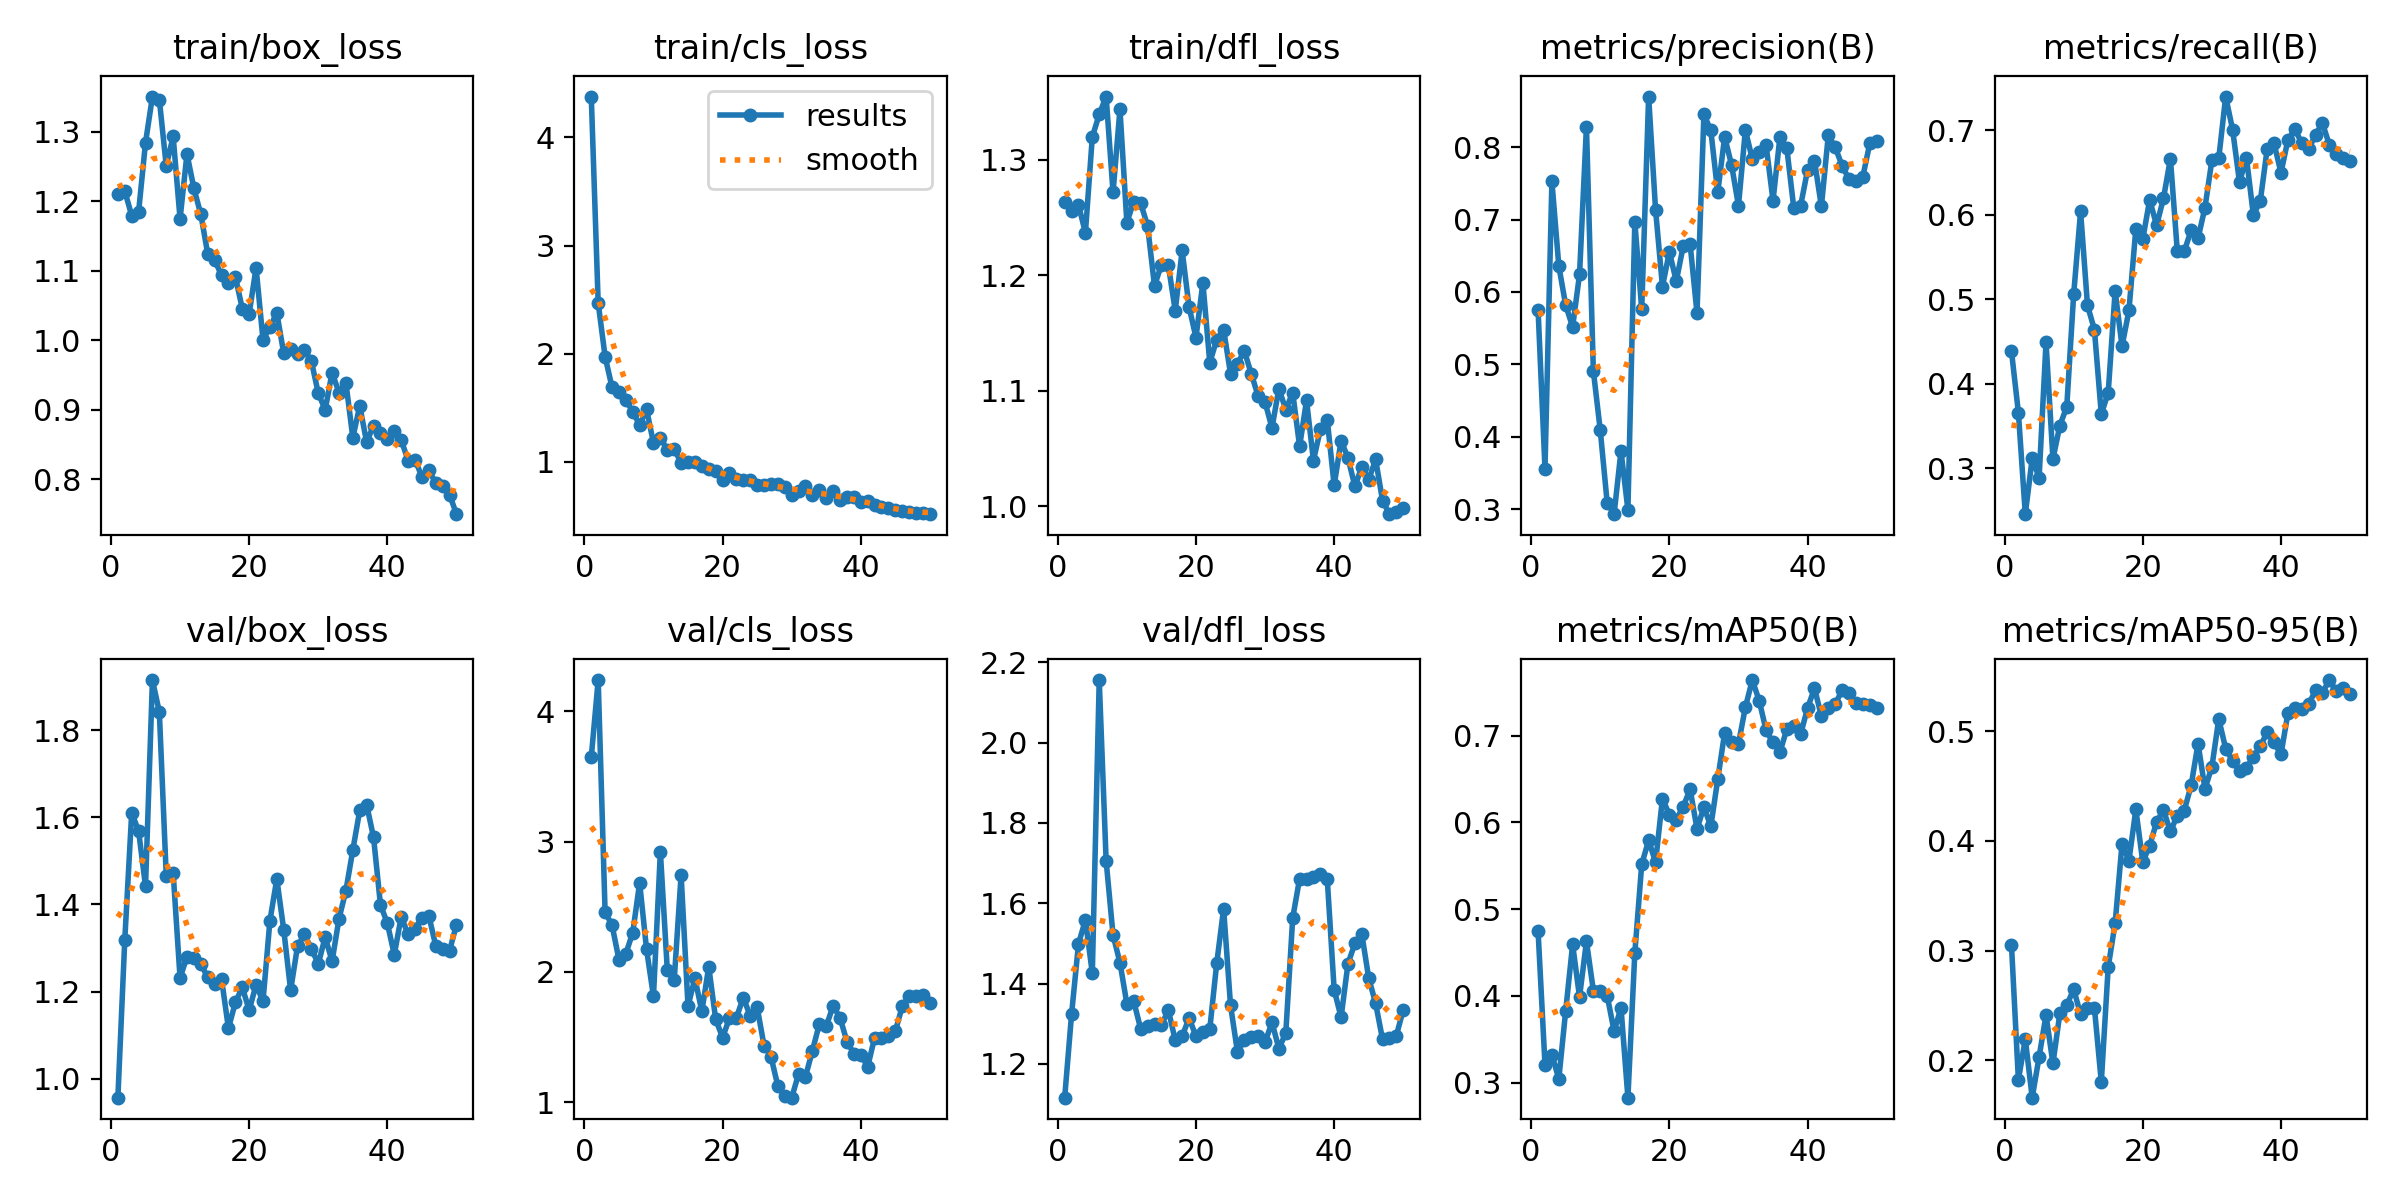

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/day_baseline/run3_small/results.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os


os.makedirs("/content/drive/MyDrive/vehicle_detection/baseline", exist_ok=True)


shutil.copy(
    "/content/runs/detect/day_baseline/run1/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/baseline/run1_nano_640.pt"
)
shutil.copy(
    "/content/runs/detect/day_baseline/run2_imgsz1280/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/baseline/run2_nano_1280.pt"
)
shutil.copy(
    "/content/runs/detect/day_baseline/run3_small/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/baseline/run3_small_1280.pt"
)



Added additional photos of trucks and buses to the daydataset

In [ ]:
rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
project = rf.workspace("polinas-workspace").project("day_dataset_1")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to day_dataset_1-1 in yolov11:: 100%|██████████| 407/407 [00:01<00:00, 228.18it/s]


In [ ]:

model = YOLO("yolo11s.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="day_extended",
    name="run1_small_1280",
    verbose=True
)

metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_dataset_1-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1_small_1280, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

Now I'm training the first version of the nightly dataset (124 photos)

In [ ]:
rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
project = rf.workspace("polinas-workspace").project("night_dataset_1")
version = project.version(1)
dataset = version.download("yolov11")

from ultralytics import YOLO

model = YOLO("yolo11s.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="night_baseline",
    name="run1_small_1280",
    verbose=True
)


metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")



loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/night_dataset_1-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1_small_1280-3, nbs=64, nms=False,

In [ ]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/vehicle_detection/baseline", exist_ok=True)
shutil.copy(
    "/content/runs/detect/night_baseline/run1_small_1280/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/baseline/night_run1_small_1280.pt"
)


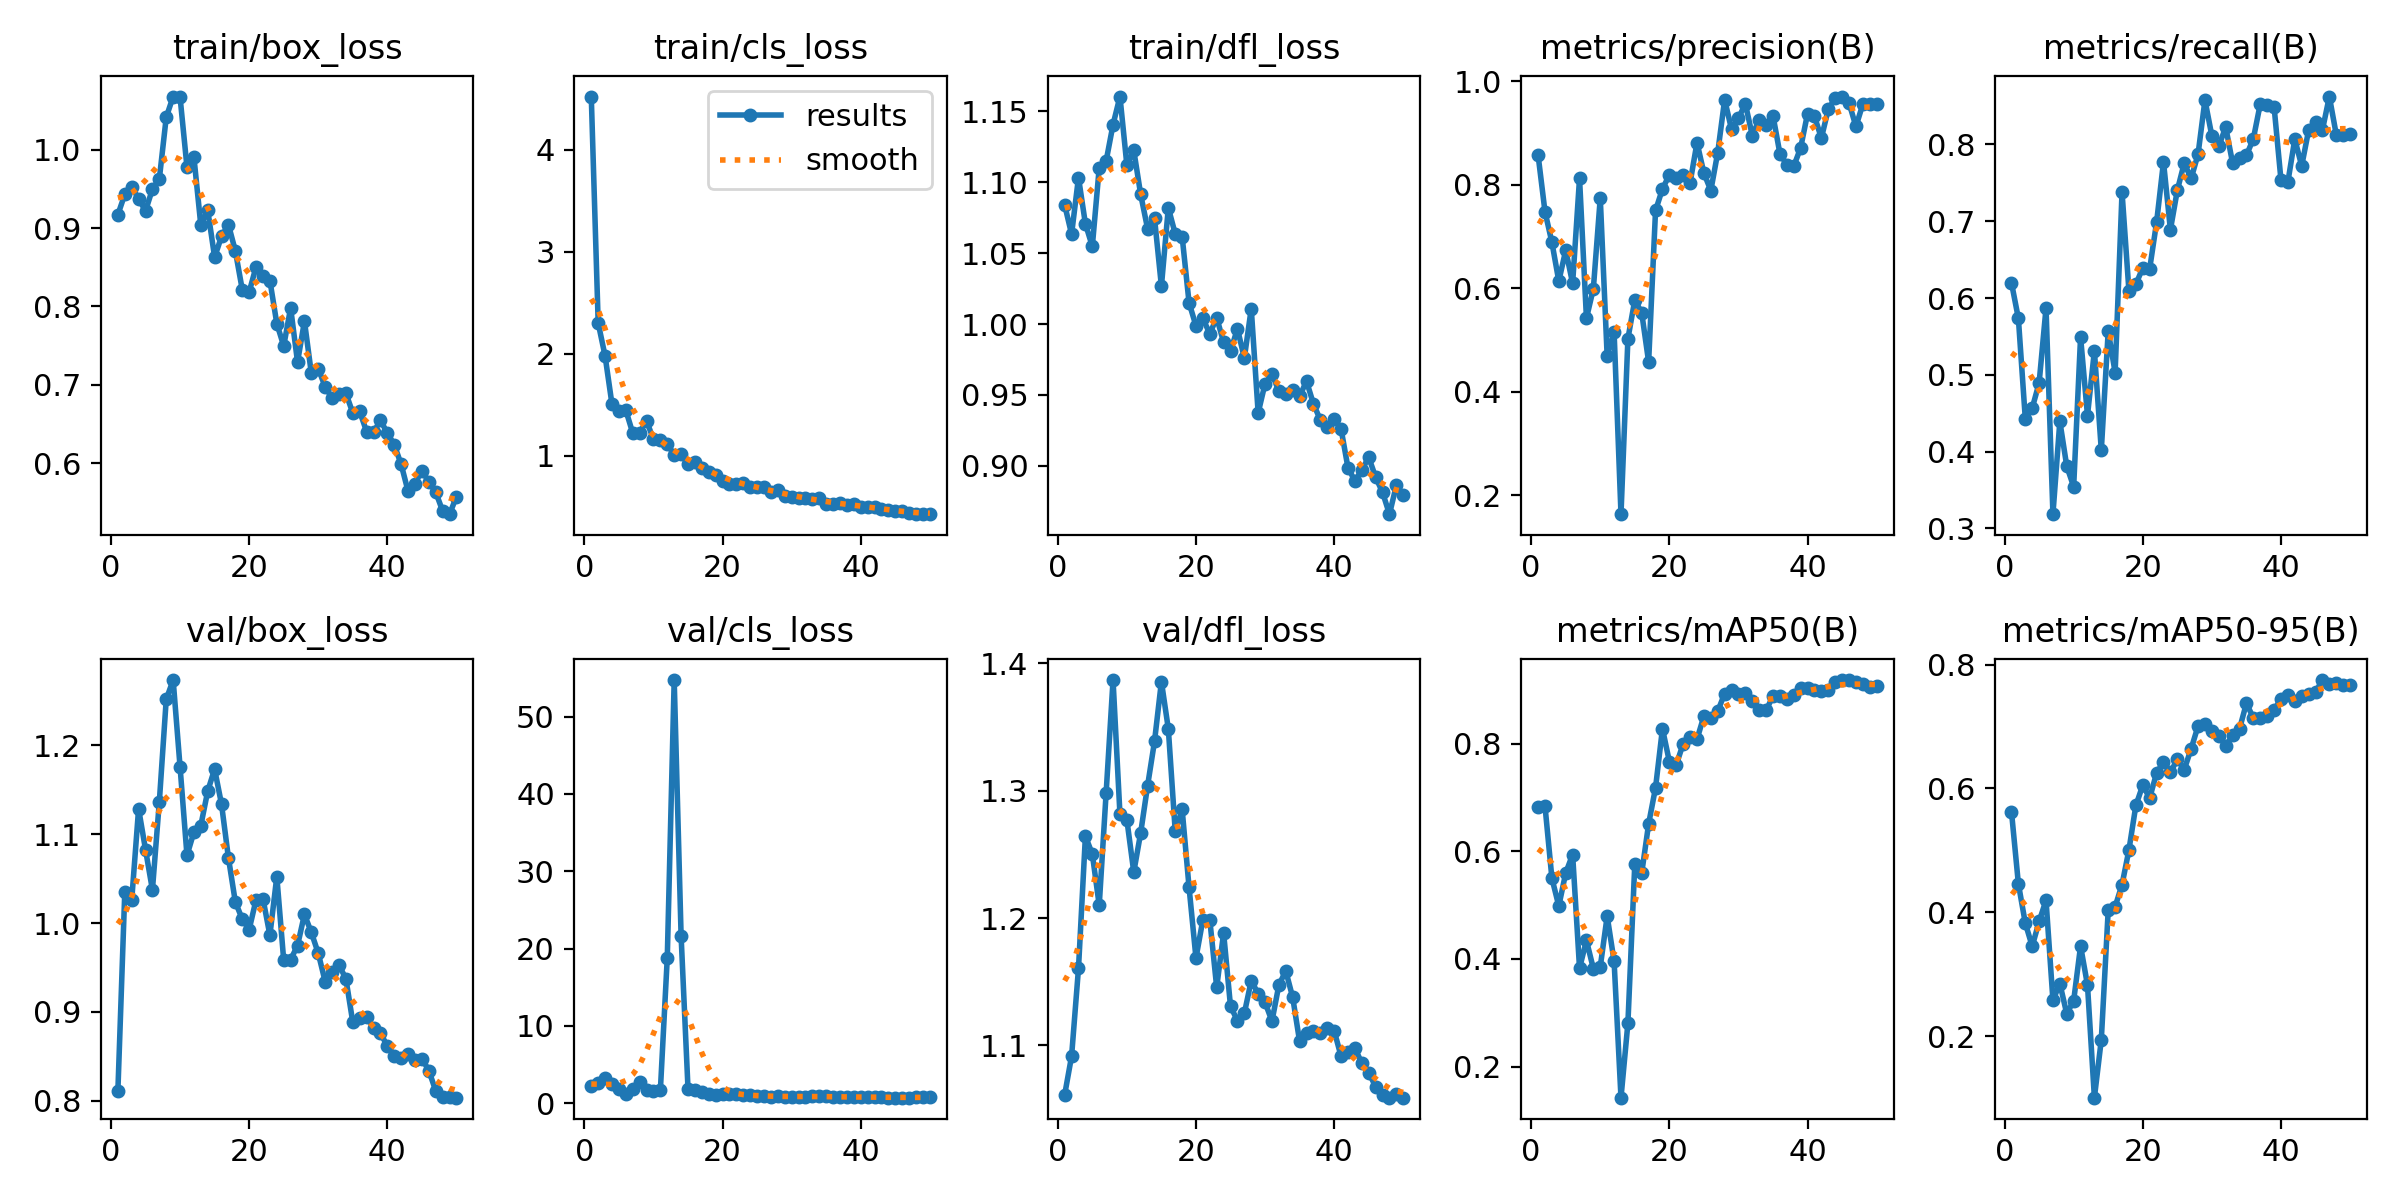

In [ ]:
from IPython.display import Image
Image("/content/runs/detect/night_baseline/run1_small_1280/results.png")

Training a daily dataset with augmentations

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from ultralytics import YOLO


rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
project_day = rf.workspace("polinas-workspace").project("day_dataset_1")
dataset_day = project_day.version(1).download("yolov11")

model = YOLO("yolo11s.pt")

model.train(
    data=f"{dataset_day.location}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="day_augmented",
    name="run1_augmented",
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
    degrees=5.0,
    translate=0.1,
    verbose=True
)

metrics = model.val()

print(f"mAP50:      {metrics.box.map50:.3f}")
print(f"mAP50-95:   {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(["car", "truck", "bus"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_dataset_1-1/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1_augmented, nbs=64, nms=False, opse

Check results on cutted daily dataset with 124 photos

In [ ]:
import random
import shutil
from pathlib import Path
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')


day_train = list(Path(f"{dataset_day.location}/train/images").iterdir())
day_valid = list(Path(f"{dataset_day.location}/valid/images").iterdir())
day_all = day_train + day_valid

random.seed(42)
day_sample = random.sample(day_all, 124)


split = int(len(day_sample) * 0.8)
day_sample_train = day_sample[:split]
day_sample_valid = day_sample[split:]

small_day_path = "/content/day_small"
for split_name in ["train", "valid"]:
    os.makedirs(f"{small_day_path}/{split_name}/images", exist_ok=True)
    os.makedirs(f"{small_day_path}/{split_name}/labels", exist_ok=True)

for img_path in day_sample_train:
    shutil.copy(img_path, f"{small_day_path}/train/images/{img_path.name}")
    lbl = Path(str(img_path).replace("images", "labels").replace(".jpg", ".txt"))
    if lbl.exists():
        shutil.copy(lbl, f"{small_day_path}/train/labels/{lbl.name}")

for img_path in day_sample_valid:
    shutil.copy(img_path, f"{small_day_path}/valid/images/{img_path.name}")
    lbl = Path(str(img_path).replace("images", "labels").replace(".jpg", ".txt"))
    if lbl.exists():
        shutil.copy(lbl, f"{small_day_path}/valid/labels/{lbl.name}")

with open(f"{small_day_path}/data.yaml", "w") as f:
    f.write(f"train: {small_day_path}/train/images\n")
    f.write(f"val: {small_day_path}/valid/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

print(f"Train: {len(day_sample_train)} фото")
print(f"Valid: {len(day_sample_valid)} фото")


model_day_small = YOLO("yolo11s.pt")
model_day_small.train(
    data=f"{small_day_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="day_small",
    name="run1",
    verbose=True
)

metrics = model_day_small.val()
print("\n===== ДНЕВНАЯ НА 124 ФОТО =====")
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 99 фото
Valid: 25 фото
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/day_small/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11

Creating and training a new night model, 196 photos

In [ ]:
import os, shutil
from pathlib import Path

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")


dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")

print("Ночной 1:", dataset_night1.location)
print("Ночной 2:", dataset_night2.location)


night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

for split in ["train", "valid", "test"]:
    n = len(list(Path(f"{night_combined_path}/{split}/images").iterdir()))
    print(f"{split}: {n} изображений")

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset_night-4 in yolov11:: 100%|██████████| 149/149 [00:00<00:00, 284.57it/s]


Ночной 1: /content/night_dataset_1-1
Ночной 2: /content/dataset_night-4
train: 137 изображений
valid: 39 изображений
test: 20 изображений


In [ ]:
from pathlib import Path

label_files = list(Path(f"{night_combined_path}/train/labels").iterdir()) + \
              list(Path(f"{night_combined_path}/valid/labels").iterdir()) + \
              list(Path(f"{night_combined_path}/test/labels").iterdir())

class_counts = {0: 0, 1: 0, 2: 0}

for lbl_path in label_files:
    with open(lbl_path) as f:
        for line in f:
            cls = int(line.strip().split()[0])
            if cls in class_counts:
                class_counts[cls] += 1

print("Распределение классов в объединённом ночном датасете:")
print(f"  bus:   {class_counts[0]}")
print(f"  car:   {class_counts[1]}")
print(f"  truck: {class_counts[2]}")
print(f"  всего: {sum(class_counts.values())}")

Распределение классов в объединённом ночном датасете:
  bus:   61
  car:   732
  truck: 72
  всего: 865


Now I'm training basic night vision without augmentations.

In [ ]:
from ultralytics import YOLO
from google.colab import drive
import shutil, os

drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/vehicle_detection/new_baseline", exist_ok=True)

model = YOLO("yolo11s.pt")

model.train(
    data=f"{night_combined_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="night_new_baseline",
    name="run1",
    verbose=True
)

metrics = model.val()


print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

shutil.copy(
    "/content/runs/detect/night_new_baseline/run1/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/night_combined/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mos

'/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt'

New night model with augmentations

In [ ]:
model = YOLO("yolo11s.pt")

model.train(
    data=f"{night_combined_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="night_new_augmented",
    name="run1",
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
    degrees=5.0,
    translate=0.1,
    verbose=True
)

metrics = model.val()


print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics.box.maps[i]:.3f}")

Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/night_combined/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

Mixed model without augmentations

In [ ]:
!pip install ultralytics roboflow -q

from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import drive

from pathlib import Path
from google.colab import drive
import os, shutil

drive.mount('/content/drive')
model = YOLO("yolo11s.pt")
rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")

night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

mixed_new_path = "/content/mixed_new"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{mixed_new_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{mixed_new_path}/{split}/labels", exist_ok=True)

for source in [dataset_day.location, night_combined_path]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{mixed_new_path}/{split}/{folder}/{f.name}")

with open(f"{mixed_new_path}/data.yaml", "w") as f:
    f.write(f"train: {mixed_new_path}/train/images\n")
    f.write(f"val: {mixed_new_path}/valid/images\n")
    f.write(f"test: {mixed_new_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

for split in ["train", "valid", "test"]:
    n = len(list(Path(f"{mixed_new_path}/{split}/images").iterdir()))
    print(f"{split}: {n} изображений")


model = YOLO("yolo11s.pt")
model.train(
    data=f"{mixed_new_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="mixed_new_baseline",
    name="run1",
    verbose=True
)

print('Валидация')
metrics_val = model.val(split="val")
print(f"mAP50:    {metrics_val.box.map50:.3f}")
print(f"mAP50-95: {metrics_val.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_val.box.maps[i]:.3f}")

print('Тест')
metrics_test = model.val(split="test")
print(f"mAP50:    {metrics_test.box.map50:.3f}")
print(f"mAP50-95: {metrics_test.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_test.box.maps[i]:.3f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
train: 288 изображений
valid: 72 изображений
test: 37 изображений
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=

Mixed model with augmentations

In [ ]:
from pathlib import Path
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")

night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


mixed_new_path = "/content/mixed_new"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{mixed_new_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{mixed_new_path}/{split}/labels", exist_ok=True)

for source in [dataset_day.location, night_combined_path]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{mixed_new_path}/{split}/{folder}/{f.name}")

with open(f"{mixed_new_path}/data.yaml", "w") as f:
    f.write(f"train: {mixed_new_path}/train/images\n")
    f.write(f"val: {mixed_new_path}/valid/images\n")
    f.write(f"test: {mixed_new_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


model = YOLO("yolo11s.pt")
model.train(
    data=f"{mixed_new_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="mixed_new_augmented",
    name="run1",
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
    degrees=5.0,
    translate=0.1,
    verbose=True
)

metrics_val = model.val(split="val")
print(f"mAP50:    {metrics_val.box.map50:.3f}")
print(f"mAP50-95: {metrics_val.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_val.box.maps[i]:.3f}")

metrics_test = model.val(split="test")
print(f"mAP50:    {metrics_test.box.map50:.3f}")
print(f"mAP50-95: {metrics_test.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_test.box.maps[i]:.3f}")

shutil.copy(
    "/content/runs/detect/mixed_new_augmented/run1/weights/best.pt",
    "/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_aug.pt"
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mixed_new/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=1280,

'/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_aug.pt'

Train mixed model with augmentations and without mosaic

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from ultralytics import YOLO
from pathlib import Path
import os, shutil

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")


night_combined_path = "/kaggle/working/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


mixed_new_path = "/kaggle/working/mixed_new"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{mixed_new_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{mixed_new_path}/{split}/labels", exist_ok=True)

for source in [dataset_day.location, night_combined_path]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{mixed_new_path}/{split}/{folder}/{f.name}")

with open(f"{mixed_new_path}/data.yaml", "w") as f:
    f.write(f"train: {mixed_new_path}/train/images\n")
    f.write(f"val: {mixed_new_path}/valid/images\n")
    f.write(f"test: {mixed_new_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


model = YOLO("yolo11s.pt")
model.train(
    data=f"{mixed_new_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="/kaggle/working/mixed_no_mosaic",
    name="run1",
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
    degrees=5.0,
    translate=0.1,
    mosaic=0.0,
    verbose=True
)

metrics_val = model.val(split="val")
print(f"mAP50:    {metrics_val.box.map50:.3f}")
print(f"mAP50-95: {metrics_val.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_val.box.maps[i]:.3f}")

metrics_test = model.val(split="test")
print(f"mAP50:    {metrics_test.box.map50:.3f}")
print(f"mAP50-95: {metrics_test.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_test.box.maps[i]:.3f}")

shutil.copy(
    "/kaggle/working/mixed_no_mosaic/run1/weights/best.pt",
    "/kaggle/working/mixed_no_mosaic.pt"
)

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/mixed_new/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

'/kaggle/working/mixed_no_mosaic.pt'

Cross-domain evaluation

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from ultralytics import YOLO
from pathlib import Path
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")

night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


model_day = YOLO("/content/drive/MyDrive/vehicle_detection/baseline/day_final_small_1280.pt")
model_night = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt")
model_mixed = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_no_aug.pt")




m = model_day.val(data=f"{night_combined_path}/data.yaml", imgsz=1280, verbose=False)
print(f"\nДневная на ночных:    mAP50 = {m.box.map50:.3f}")


m = model_night.val(data=f"{dataset_day.location}/data.yaml", imgsz=1280, verbose=False)
print(f"Ночная на дневных:    mAP50 = {m.box.map50:.3f}")


m = model_mixed.val(data=f"{dataset_day.location}/data.yaml", imgsz=1280, verbose=False)
print(f"Смешанная на дневных: mAP50 = {m.box.map50:.3f}")


m = model_mixed.val(data=f"{night_combined_path}/data.yaml", imgsz=1280, verbose=False)
print(f"Смешанная на ночных:  mAP50 = {m.box.map50:.3f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
===== КРОСС-ДОМЕННОЕ ТЕСТИРОВАНИЕ =====
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2057.6±1070.4 MB/s, size: 1543.4 KB)
val: Scanning /content/night_combined/valid/labels... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 738.1it/s 0.1s
val: New cache created: /content/night_combined/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 40.4s/it 2:01
                   all         39        161      0.857      0.603      0.687  

F1 analysis

In [ ]:
model_day.val(
    data=f"{dataset_day.location}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="day",
    verbose=False
)

import glob
f1_files = glob.glob("/content/f1_results/**/F1_curve.png", recursive=True)
print(f1_files)


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1389.2±730.1 MB/s, size: 2900.8 KB)
val: Scanning /content/day_dataset_1-1/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 23.8s/it 1:11
                   all         33        210        0.9      0.775      0.858       0.65
Speed: 35.5ms preprocess, 1924.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/f1_results/day
[]


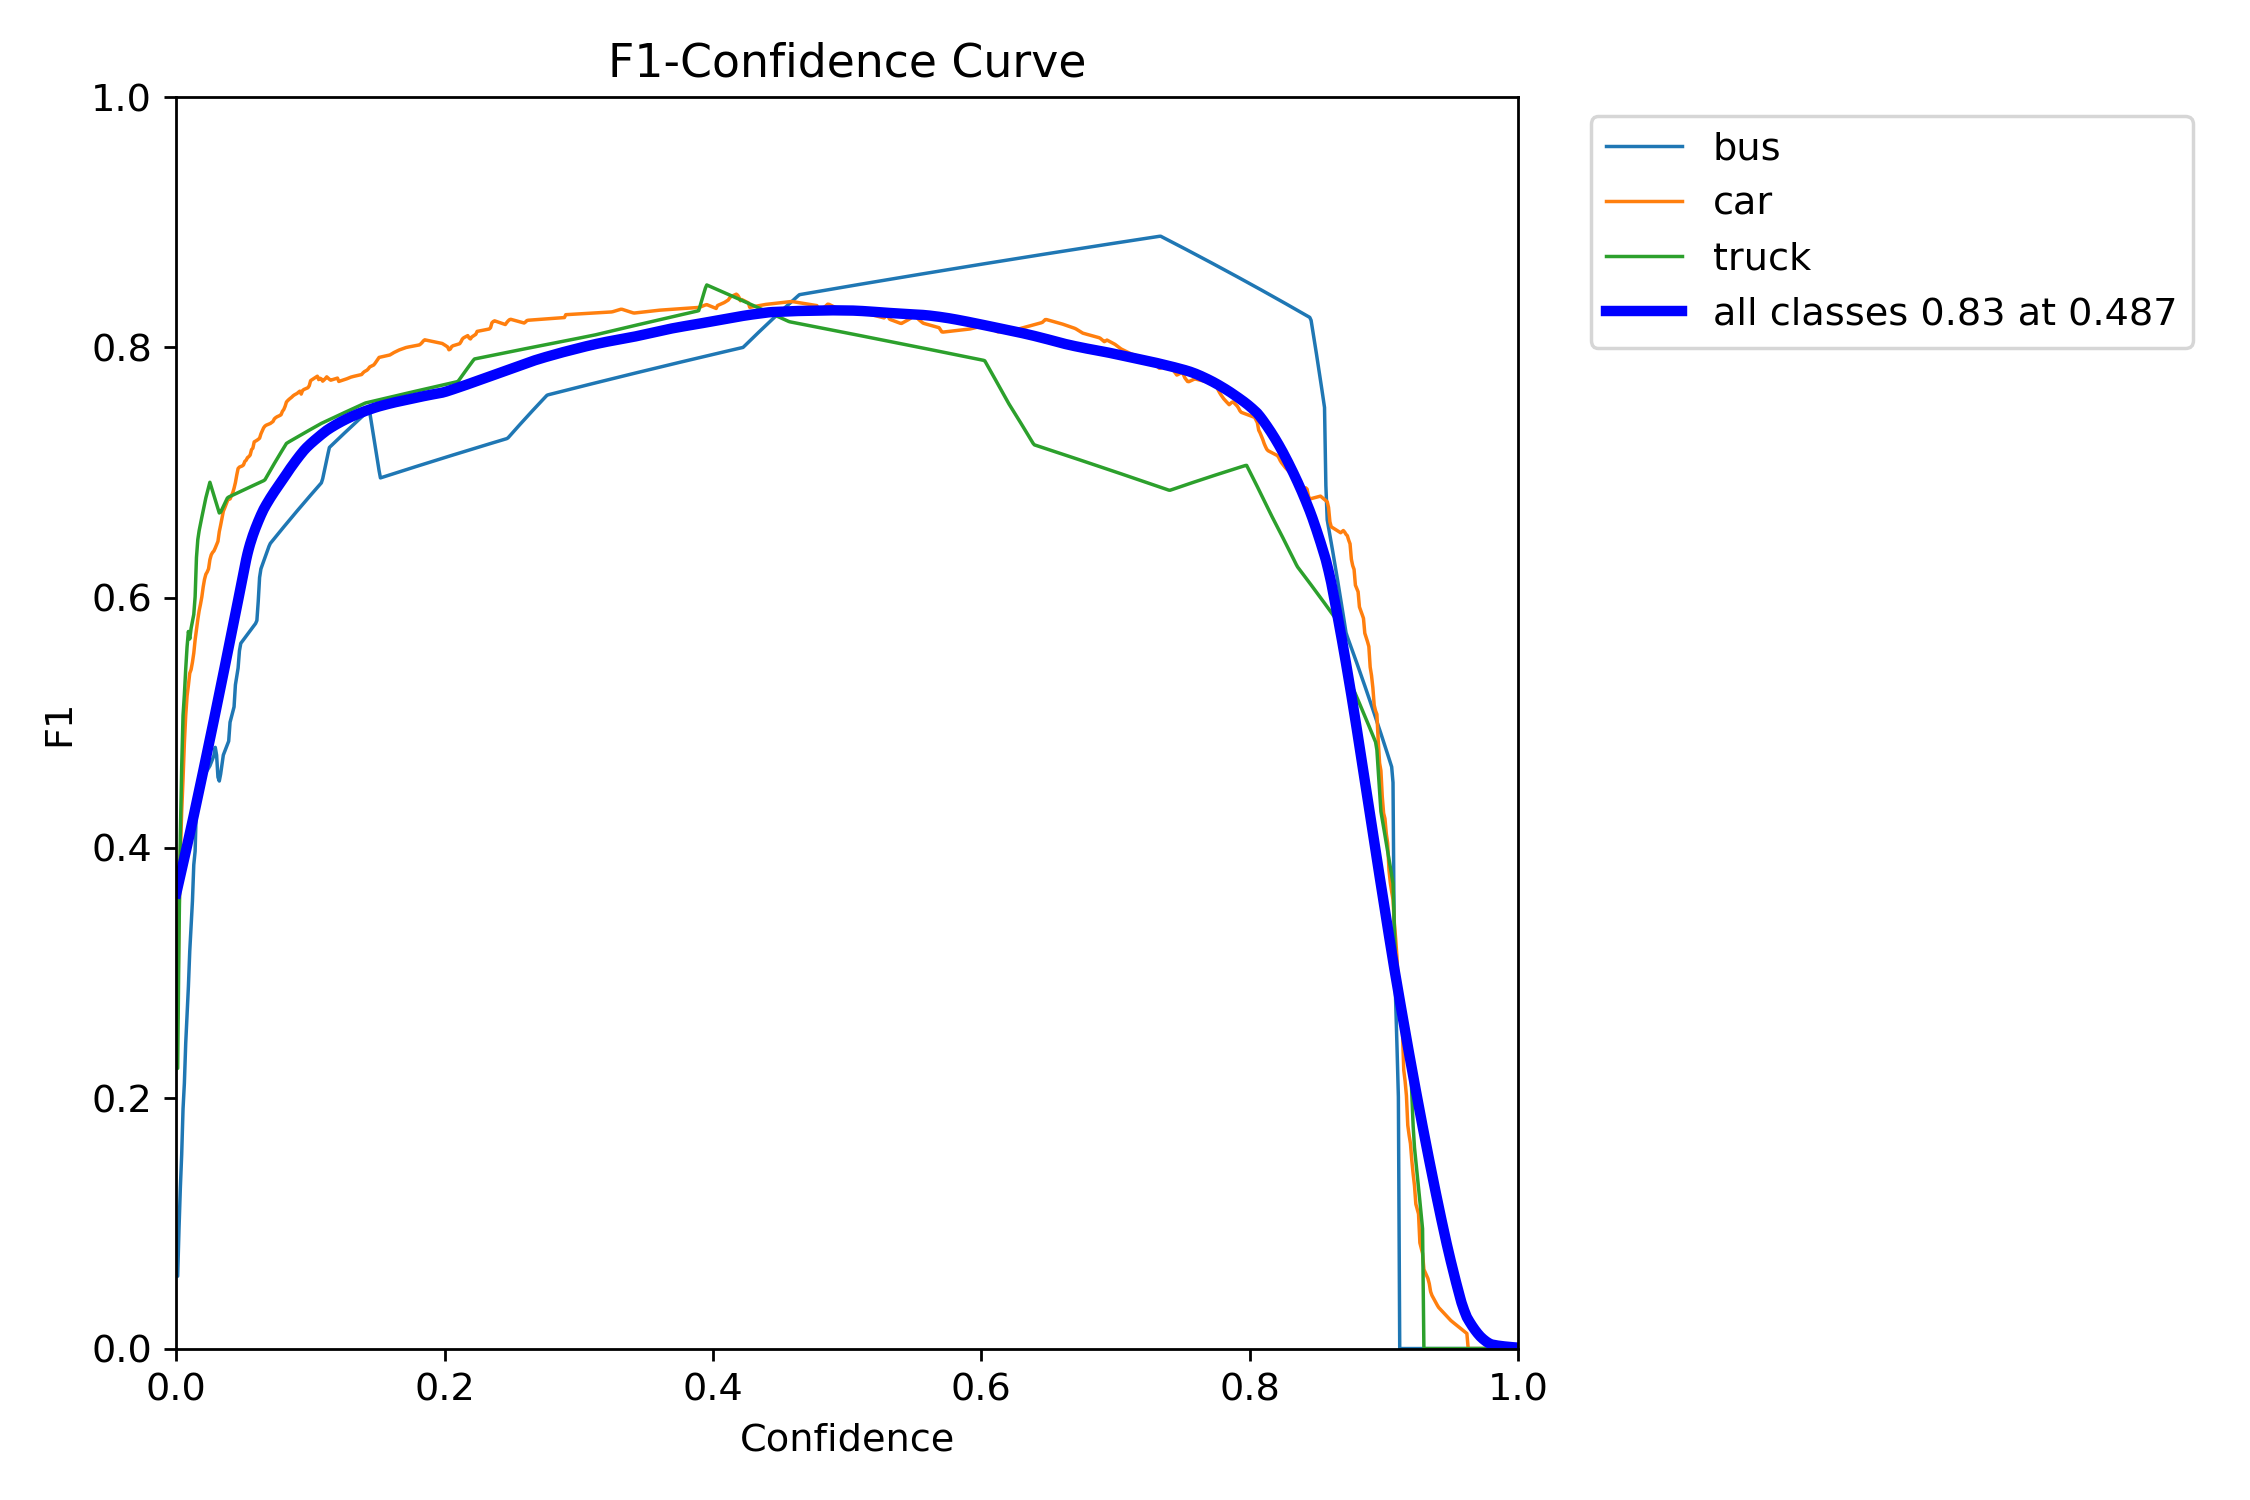

In [ ]:
from IPython.display import Image
Image("/content/f1_results/day/BoxF1_curve.png", width=700)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 930.3±574.1 MB/s, size: 1659.4 KB)
val: Scanning /content/night_combined/valid/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 6.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 25.4s/it 1:16
                   all         39        161       0.92      0.756      0.835      0.638
Speed: 19.3ms preprocess, 1712.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/f1_results/night


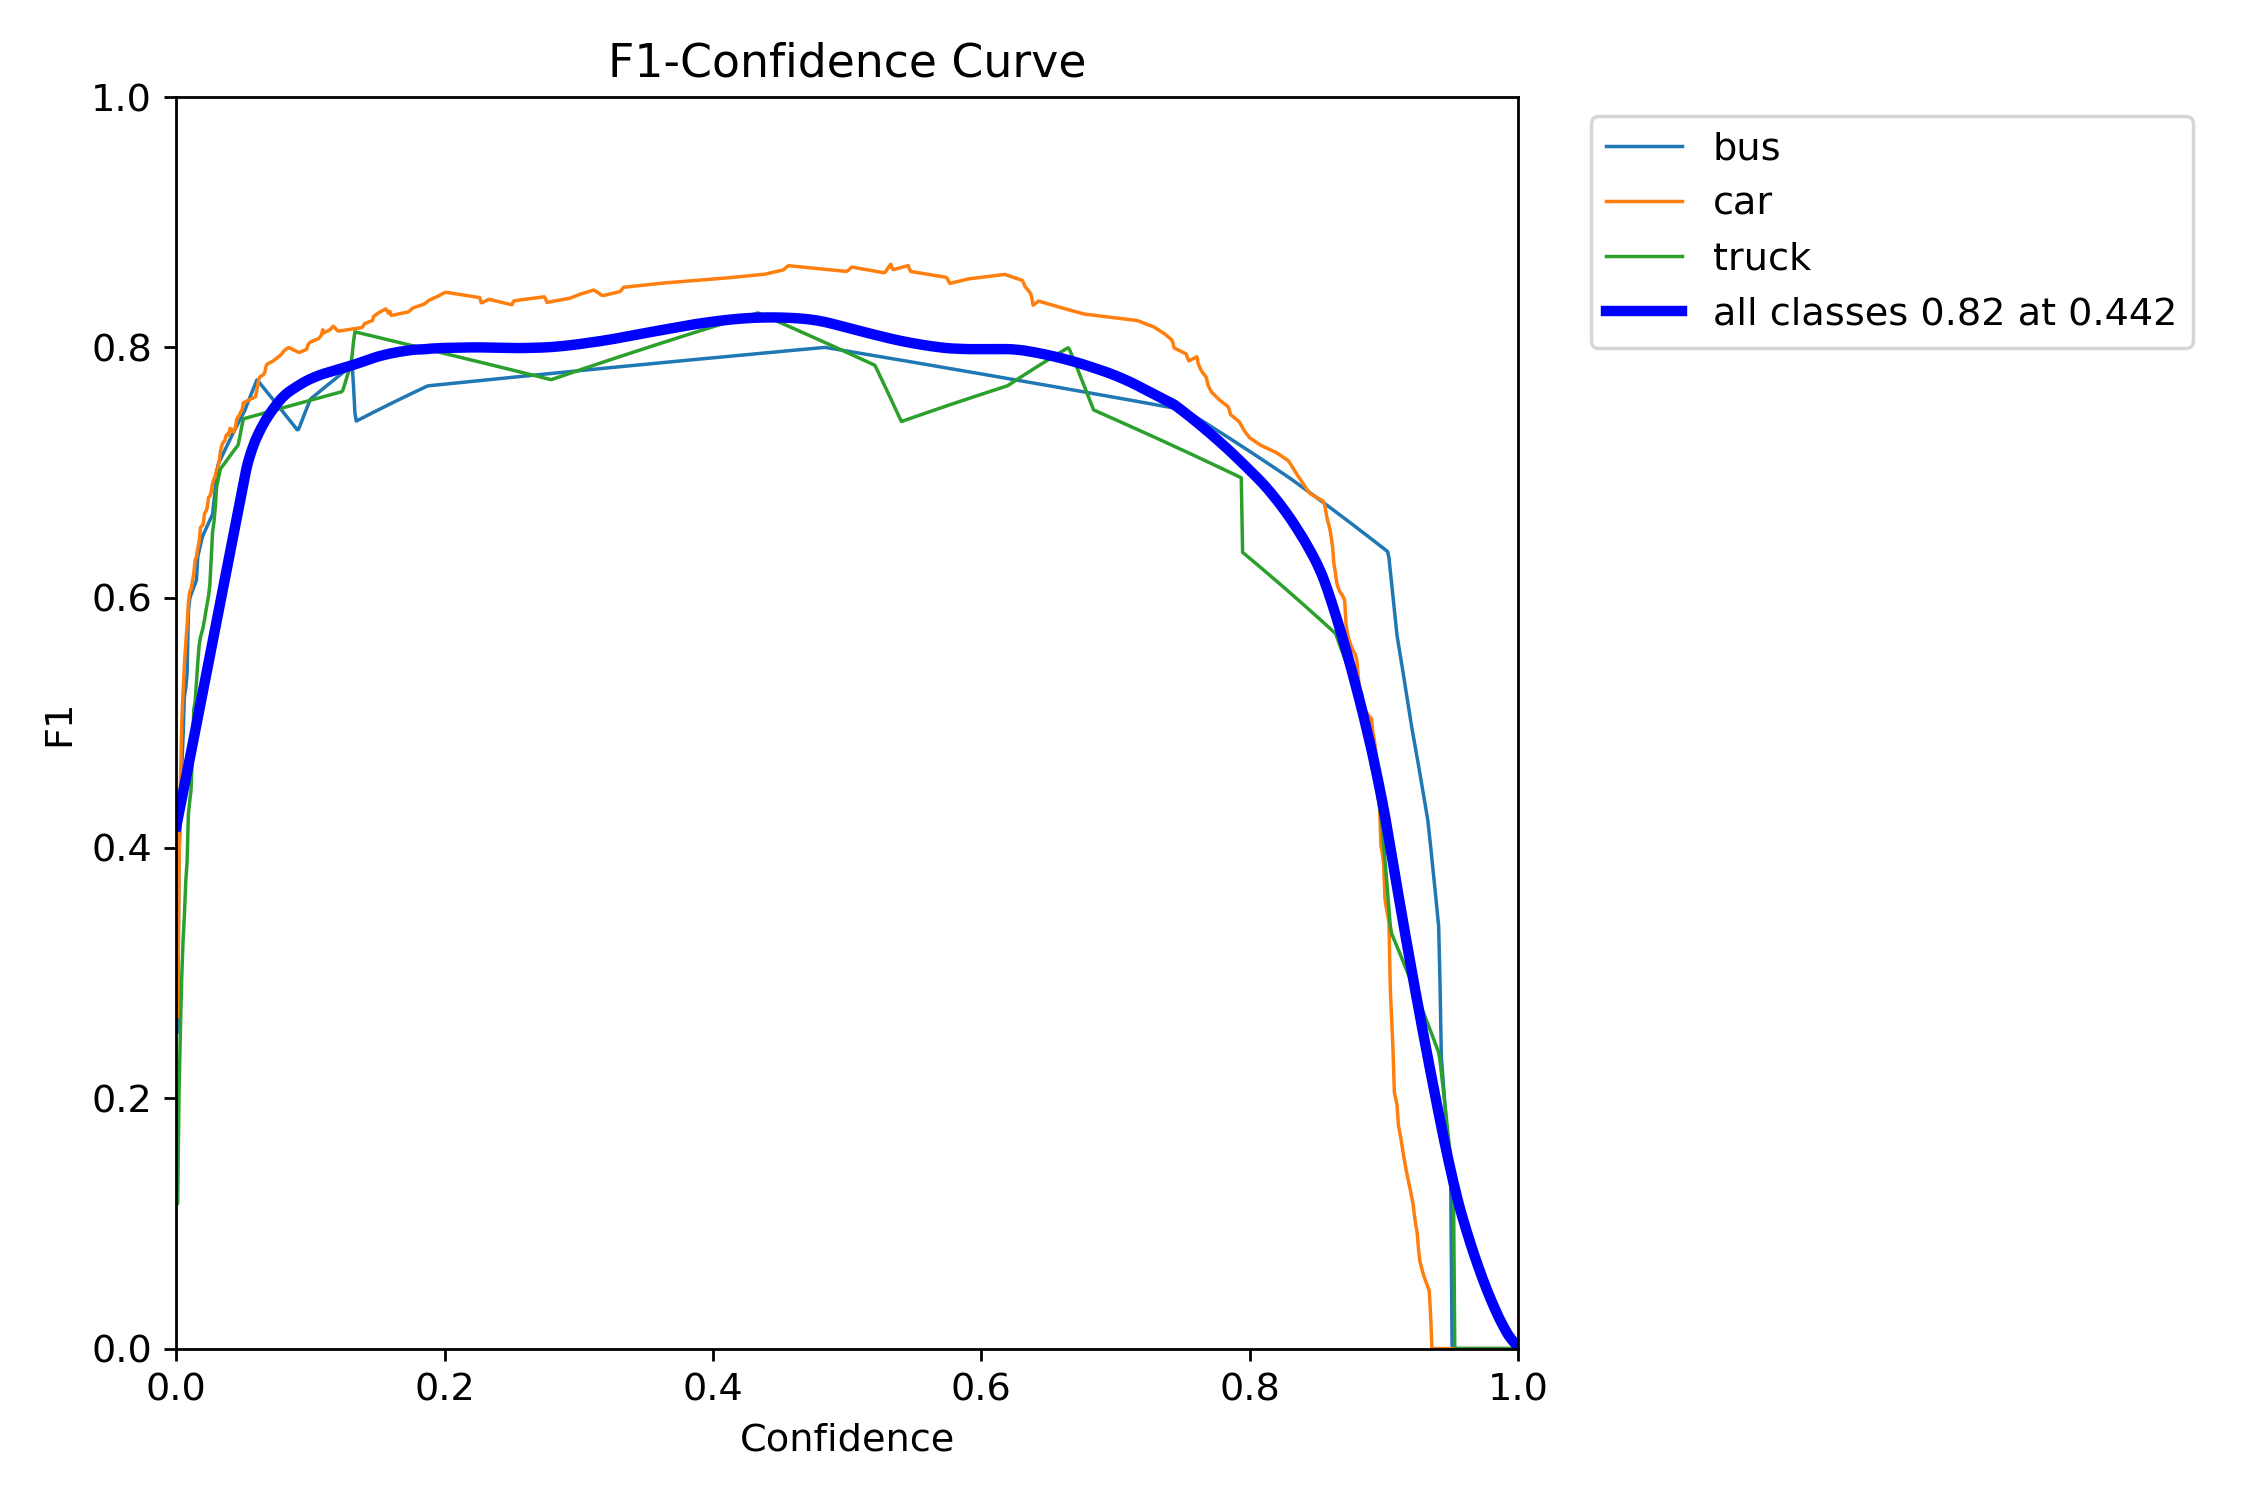

In [ ]:
model_night = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt")

model_night.val(
    data=f"{night_combined_path}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="night",
    verbose=False
)

Image("/content/f1_results/night/BoxF1_curve.png", width=700)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 398.0±218.2 MB/s, size: 1965.2 KB)
val: Scanning /content/mixed_new/valid/labels.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 10.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 28.2s/it 2:21
                   all         72        371      0.893      0.769      0.831      0.651
Speed: 5.5ms preprocess, 1775.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/f1_results/mixed
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2182.1±406.3 MB/s, size: 1873.2 KB)
val: Scanning /content/night_combined/valid/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 8.2Mit/s 0.0s
                 Class     Images  Instances      Bo

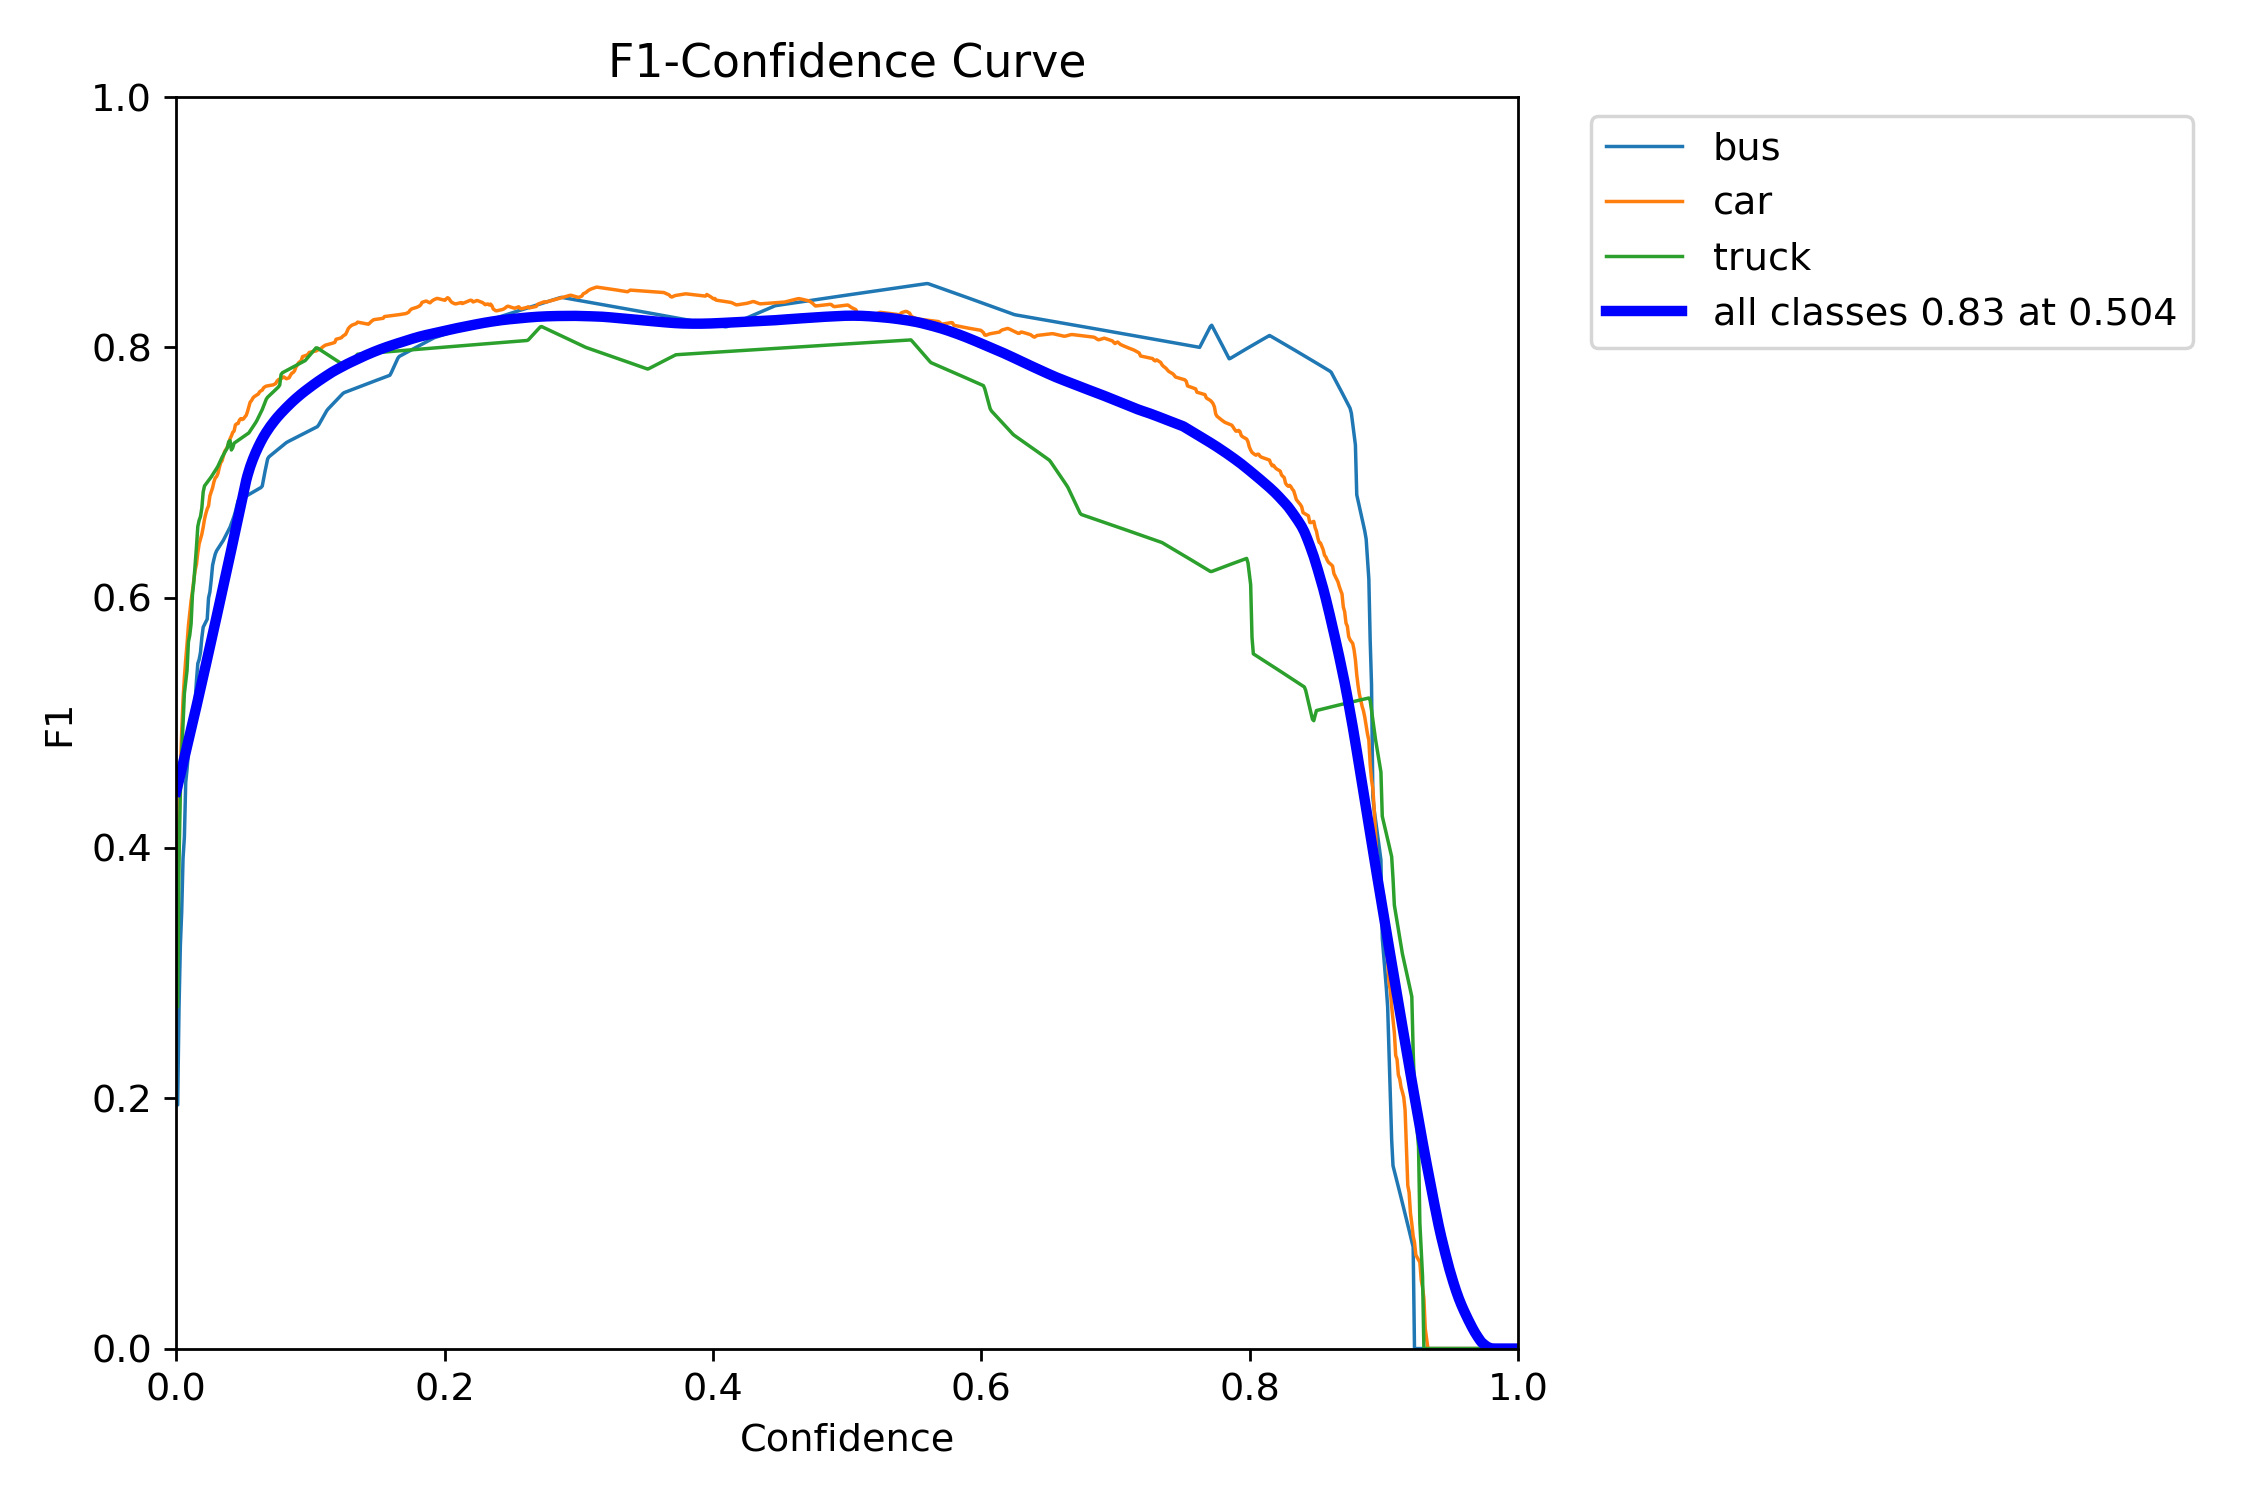

Дневная на ночных:


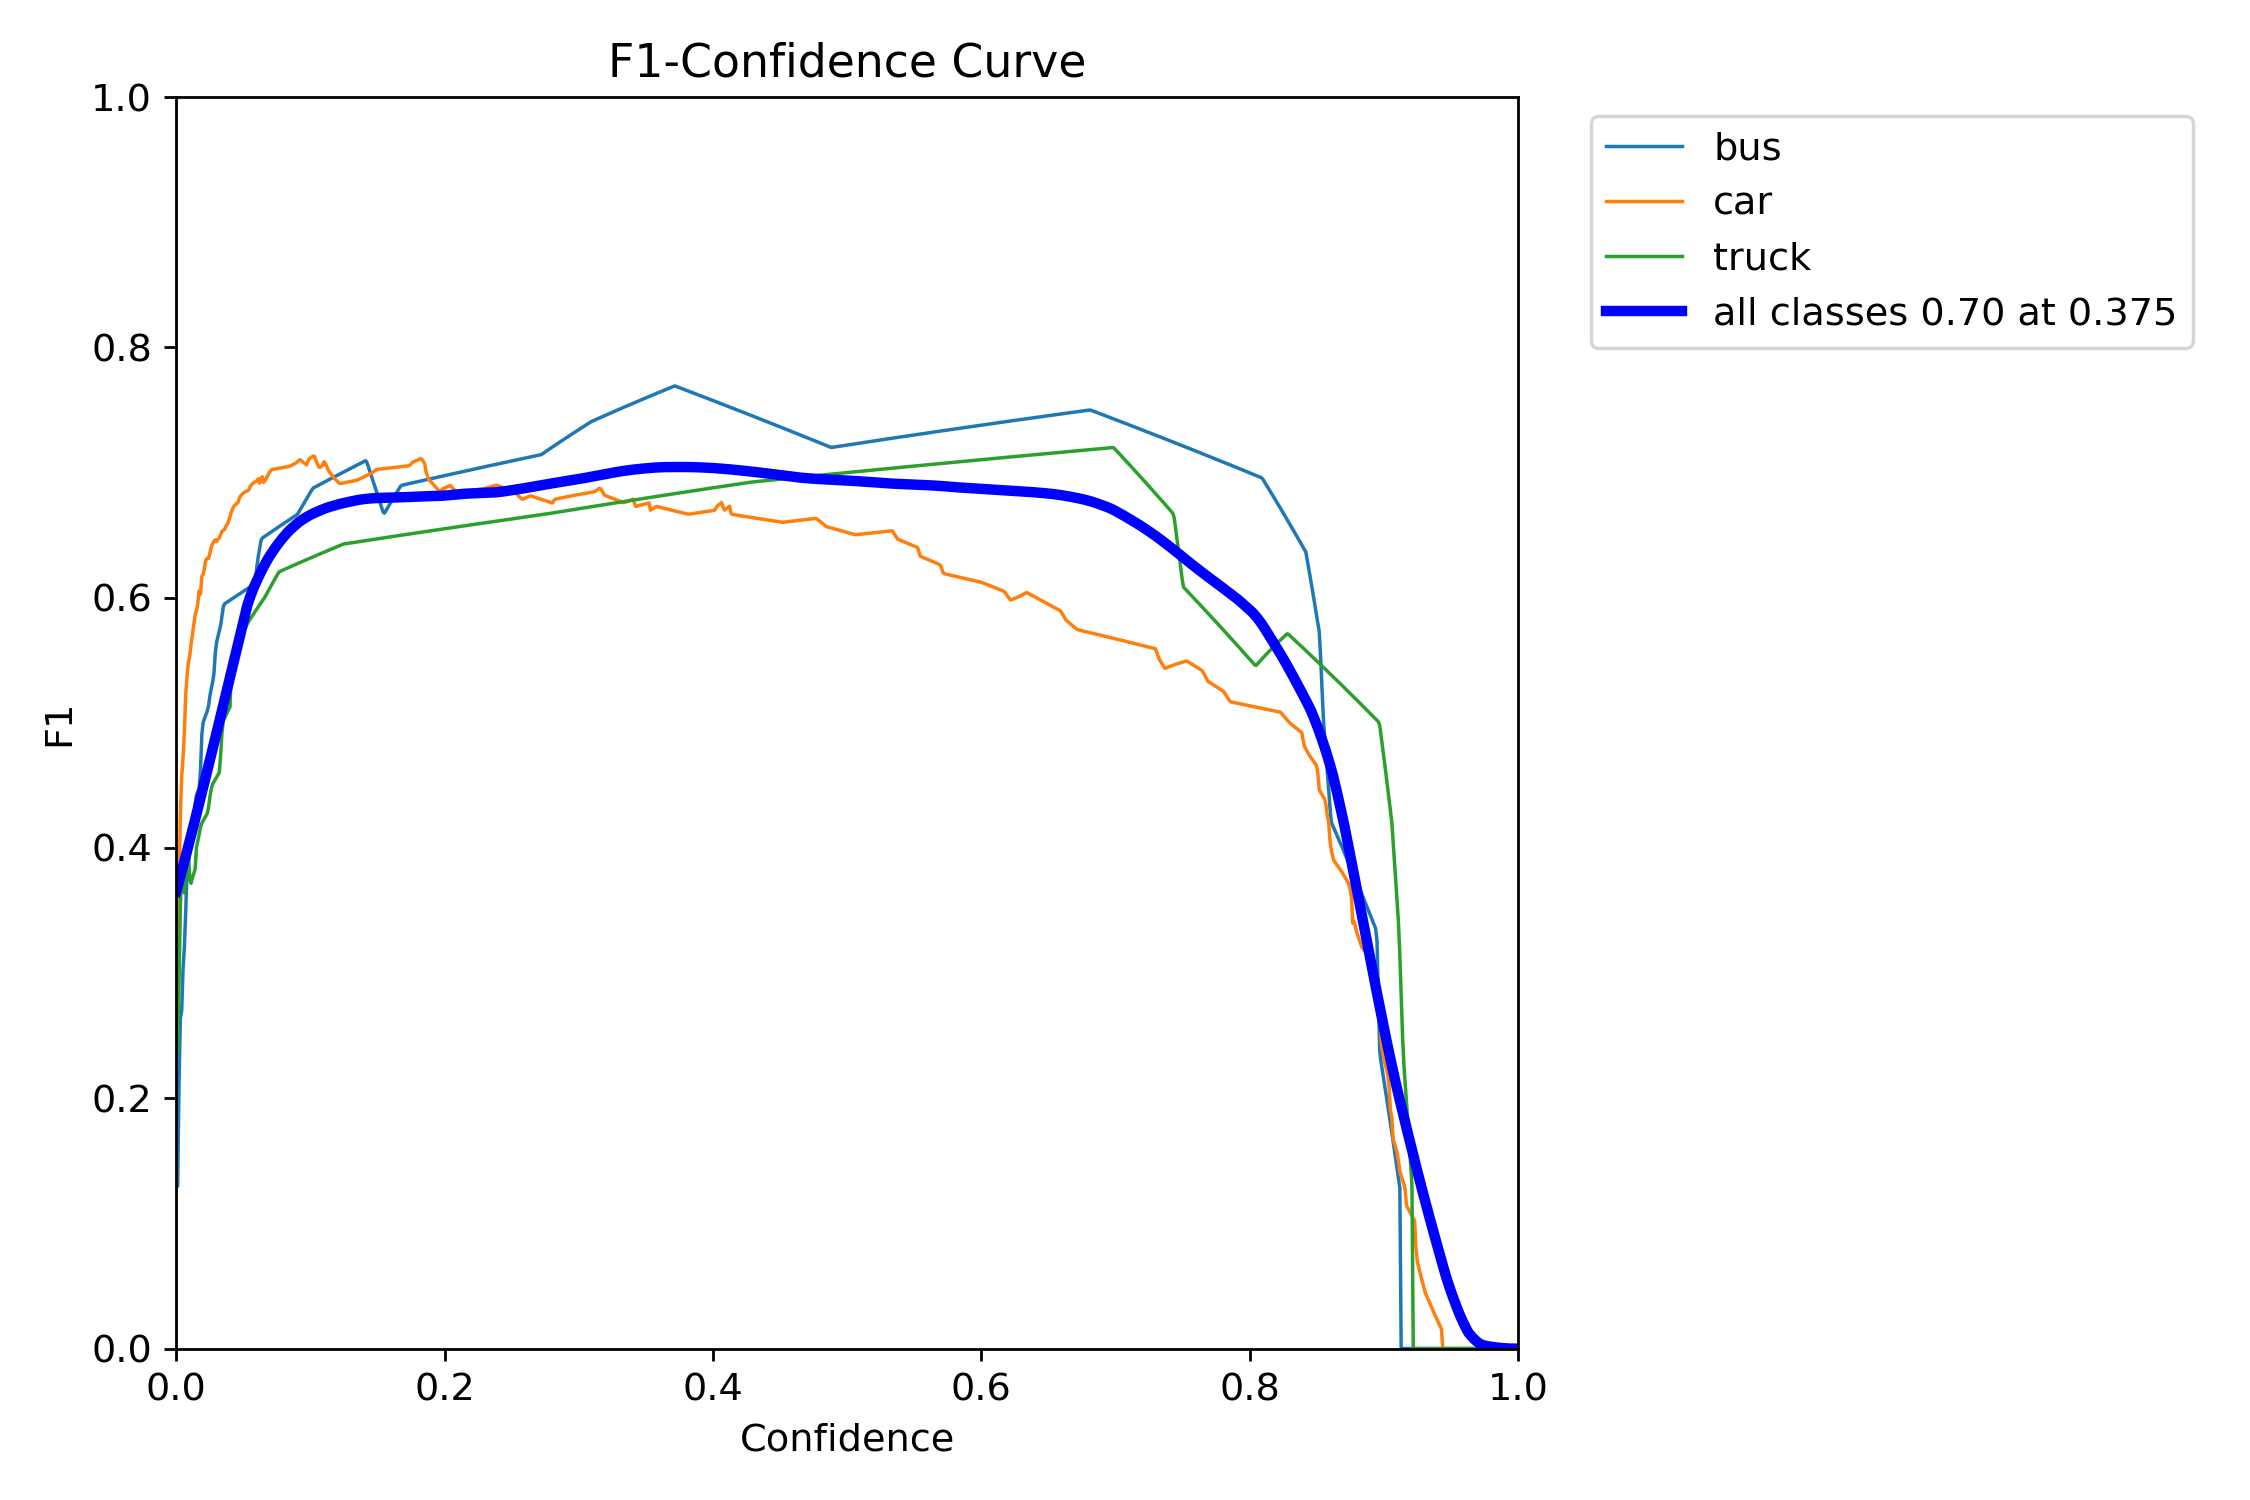

In [ ]:
model_no_aug.val(
    data=f"{mixed_new_path}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="mixed",
    verbose=False
)


model_day.val(
    data=f"{night_combined_path}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="day_on_night",
    verbose=False
)

from IPython.display import Image, display
print("Смешанная модель:")
display(Image("/content/f1_results/mixed/BoxF1_curve.png", width=700))
print("Дневная на ночных:")
display(Image("/content/f1_results/day_on_night/BoxF1_curve.png", width=700))

Recall analysis

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1341.5±1647.7 MB/s, size: 1728.4 KB)
val: Scanning /kaggle/working/night_combined/valid/labels... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 807.1it/s 0.0s
val: New cache created: /kaggle/working/night_combined/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.5s/it 10.4s
                   all         39        161      0.857      0.603      0.602      0.512
Speed: 58.0ms preprocess, 45.0ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/detect/val-7
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (

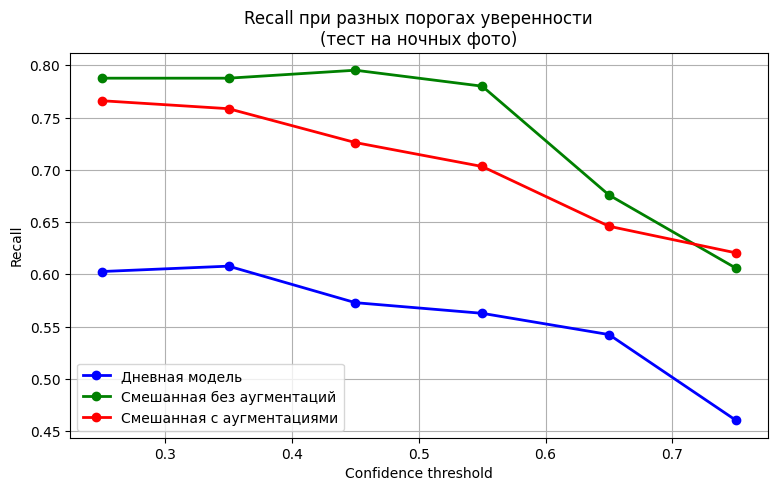

In [ ]:
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

model_day = YOLO("/content/drive/MyDrive/vehicle_detection/baseline/day_final_small_1280.pt")
model_no_aug = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_no_aug.pt")
model_aug = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_aug.pt")

conf_thresholds = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
recall_day = []
recall_mixed_no_aug = []
recall_mixed_aug = []

for conf in conf_thresholds:
    m_day = model_day.val(data=f"{night_combined_path}/data.yaml", imgsz=1280, conf=conf, verbose=False)
    m_no_aug = model_no_aug.val(data=f"{night_combined_path}/data.yaml", imgsz=1280, conf=conf, verbose=False)
    m_aug = model_aug.val(data=f"{night_combined_path}/data.yaml", imgsz=1280, conf=conf, verbose=False)
    recall_day.append(m_day.box.mr)
    recall_mixed_no_aug.append(m_no_aug.box.mr)
    recall_mixed_aug.append(m_aug.box.mr)
    print(f"conf={conf}: day={m_day.box.mr:.3f}, mixed={m_no_aug.box.mr:.3f}, mixed+aug={m_aug.box.mr:.3f}")

plt.figure(figsize=(9, 5))
plt.plot(conf_thresholds, recall_day, 'b-o', linewidth=2, label='Дневная модель')
plt.plot(conf_thresholds, recall_mixed_no_aug, 'g-o', linewidth=2, label='Смешанная без аугментаций')
plt.plot(conf_thresholds, recall_mixed_aug, 'r-o', linewidth=2, label='Смешанная с аугментациями')
plt.title('Recall при разных порогах уверенности\n(тест на ночных фото)')
plt.xlabel('Confidence threshold')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/vehicle_detection/recall_analysis_new.png", dpi=150)
plt.show()

Robustness analysis

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, shutil

def test_brightness(model, val_images, brightness_factor):
    tmp_dir = "/content/tmp_test"
    tmp_img_dir = f"{tmp_dir}/images"
    tmp_lbl_dir = f"{tmp_dir}/labels"
    os.makedirs(tmp_img_dir, exist_ok=True)
    os.makedirs(tmp_lbl_dir, exist_ok=True)
    for img_path in val_images:
        img = cv2.imread(str(img_path))
        img = np.clip(img * brightness_factor, 0, 255).astype(np.uint8)
        cv2.imwrite(f"{tmp_img_dir}/{img_path.name}", img)
    for img_path in val_images:
        lbl_path = Path(str(img_path).replace("images", "labels").replace(".jpg", ".txt"))
        if lbl_path.exists():
            shutil.copy(lbl_path, f"{tmp_lbl_dir}/{lbl_path.name}")
    with open(f"{tmp_dir}/data.yaml", "w") as f:
        f.write(f"train: {tmp_img_dir}\nval: {tmp_img_dir}\nnc: 3\nnames: ['bus', 'car', 'truck']\n")
    metrics = model.val(data=f"{tmp_dir}/data.yaml", imgsz=1280, verbose=False)
    shutil.rmtree(tmp_dir)
    return metrics.box.map50

def test_noise(model, val_images, std):
    tmp_dir = "/content/tmp_test"
    tmp_img_dir = f"{tmp_dir}/images"
    tmp_lbl_dir = f"{tmp_dir}/labels"
    os.makedirs(tmp_img_dir, exist_ok=True)
    os.makedirs(tmp_lbl_dir, exist_ok=True)
    for img_path in val_images:
        img = cv2.imread(str(img_path)).astype(np.float32)
        noise = np.random.normal(0, std, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)
        cv2.imwrite(f"{tmp_img_dir}/{img_path.name}", img)
    for img_path in val_images:
        lbl_path = Path(str(img_path).replace("images", "labels").replace(".jpg", ".txt"))
        if lbl_path.exists():
            shutil.copy(lbl_path, f"{tmp_lbl_dir}/{lbl_path.name}")
    with open(f"{tmp_dir}/data.yaml", "w") as f:
        f.write(f"train: {tmp_img_dir}\nval: {tmp_img_dir}\nnc: 3\nnames: ['bus', 'car', 'truck']\n")
    metrics = model.val(data=f"{tmp_dir}/data.yaml", imgsz=1280, verbose=False)
    shutil.rmtree(tmp_dir)
    return metrics.box.map50

def test_blur(model, val_images, ksize):
    tmp_dir = "/content/tmp_test"
    tmp_img_dir = f"{tmp_dir}/images"
    tmp_lbl_dir = f"{tmp_dir}/labels"
    os.makedirs(tmp_img_dir, exist_ok=True)
    os.makedirs(tmp_lbl_dir, exist_ok=True)
    for img_path in val_images:
        img = cv2.imread(str(img_path))
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)
        cv2.imwrite(f"{tmp_img_dir}/{img_path.name}", img)
    for img_path in val_images:
        lbl_path = Path(str(img_path).replace("images", "labels").replace(".jpg", ".txt"))
        if lbl_path.exists():
            shutil.copy(lbl_path, f"{tmp_lbl_dir}/{lbl_path.name}")
    with open(f"{tmp_dir}/data.yaml", "w") as f:
        f.write(f"train: {tmp_img_dir}\nval: {tmp_img_dir}\nnc: 3\nnames: ['bus', 'car', 'truck']\n")
    metrics = model.val(data=f"{tmp_dir}/data.yaml", imgsz=1280, verbose=False)
    shutil.rmtree(tmp_dir)
    return metrics.box.map50


brightness_levels = [1.0, 0.8, 0.6, 0.4, 0.2]
noise_levels = [0, 10, 25, 50, 75]
blur_levels = [1, 3, 5, 9, 15]

map50_brightness_no_aug = []
map50_brightness_aug = []
map50_noise_no_aug = []
map50_noise_aug = []
map50_blur_no_aug = []
map50_blur_aug = []

val_images = list(Path(f"{mixed_new_path}/valid/images").iterdir())


for level in brightness_levels:
    map50_brightness_no_aug.append(test_brightness(model_no_aug, val_images, level))
    map50_brightness_aug.append(test_brightness(model_aug, val_images, level))
    print(f"  brightness {level}: no_aug={map50_brightness_no_aug[-1]:.3f}, aug={map50_brightness_aug[-1]:.3f}")


for level in noise_levels:
    map50_noise_no_aug.append(test_noise(model_no_aug, val_images, level))
    map50_noise_aug.append(test_noise(model_aug, val_images, level))
    print(f"  noise {level}: no_aug={map50_noise_no_aug[-1]:.3f}, aug={map50_noise_aug[-1]:.3f}")


for level in blur_levels:
    map50_blur_no_aug.append(test_blur(model_no_aug, val_images, level))
    map50_blur_aug.append(test_blur(model_aug, val_images, level))
    print(f"  blur {level}: no_aug={map50_blur_no_aug[-1]:.3f}, aug={map50_blur_aug[-1]:.3f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(brightness_levels, map50_brightness_no_aug, 'b-o', linewidth=2, label='Without augmentations')
axes[0].plot(brightness_levels, map50_brightness_aug, 'r-o', linewidth=2, label='With augmentations')
axes[0].set_title('Robustness to Brightness Reduction')
axes[0].set_xlabel('Brightness coefficient (1.0 = original)')
axes[0].set_ylabel('mAP50')
axes[0].legend()
axes[0].grid(True)
axes[0].invert_xaxis()

axes[1].plot(noise_levels, map50_noise_no_aug, 'b-o', linewidth=2, label='Without augmentations')
axes[1].plot(noise_levels, map50_noise_aug, 'r-o', linewidth=2, label='With augmentations')
axes[1].set_title('Robustness to Gaussian Noise')
axes[1].set_xlabel('Noise level (std)')
axes[1].set_ylabel('mAP50')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(blur_levels, map50_blur_no_aug, 'b-o', linewidth=2, label='Without augmentations')
axes[2].plot(blur_levels, map50_blur_aug, 'r-o', linewidth=2, label='With augmentations')
axes[2].set_title('Robustness to Gaussian Blur')
axes[2].set_xlabel('Kernel size')
axes[2].set_ylabel('mAP50')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/vehicle_detection/robustness_new.png", dpi=150)
plt.show()

 Mixed model with freeze = 10

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from ultralytics import YOLO
from pathlib import Path
import os, shutil

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")


night_combined_path = "/kaggle/working/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


mixed_new_path = "/kaggle/working/mixed_new"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{mixed_new_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{mixed_new_path}/{split}/labels", exist_ok=True)

for source in [dataset_day.location, night_combined_path]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{mixed_new_path}/{split}/{folder}/{f.name}")

with open(f"{mixed_new_path}/data.yaml", "w") as f:
    f.write(f"train: {mixed_new_path}/train/images\n")
    f.write(f"val: {mixed_new_path}/valid/images\n")
    f.write(f"test: {mixed_new_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

for split in ["train", "valid", "test"]:
    n = len(list(Path(f"{mixed_new_path}/{split}/images").iterdir()))
    print(f"{split}: {n} изображений")


model = YOLO("yolo11s.pt")
model.train(
    data=f"{mixed_new_path}/data.yaml",
    epochs=50,
    imgsz=1280,
    batch=8,
    project="/kaggle/working/mixed_freeze",
    name="run1",
    freeze=10,
    verbose=True
)

metrics_val = model.val(split="val")
print(f"mAP50:    {metrics_val.box.map50:.3f}")
print(f"mAP50-95: {metrics_val.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_val.box.maps[i]:.3f}")

metrics_test = model.val(split="test")
print(f"mAP50:    {metrics_test.box.map50:.3f}")
print(f"mAP50-95: {metrics_test.box.map:.3f}")
for i, name in enumerate(["bus", "car", "truck"]):
    print(f"  {name}: {metrics_test.box.maps[i]:.3f}")

shutil.copy(
    "/kaggle/working/mixed_freeze/run1/weights/best.pt",
    "/kaggle/working/mixed_freeze.pt"
)


Mixed with freeze (val):
mAP50:    0.857
mAP50-95: 0.665
  bus: 0.711
  car: 0.658
  truck: 0.625

Mixed with freeze (test):
mAP50:    0.612
mAP50-95: 0.434
  bus: 0.427
  car: 0.674
  truck: 0.201

Confusion matricies

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 147.9±34.5 MB/s, size: 2296.6 KB)
val: Scanning /content/day_dataset_1-1/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 245.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 24.3s/it 1:13
                   all         33        210        0.9      0.775      0.858       0.65
Speed: 40.0ms preprocess, 1903.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/confusion_matrices/day
day готово
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1176.6±319.4 MB/s, size: 1776.4 KB)
val: Scanning /content/night_combined/valid/labels.cache... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 7.4Mit/s 0.0s
                 Class     I

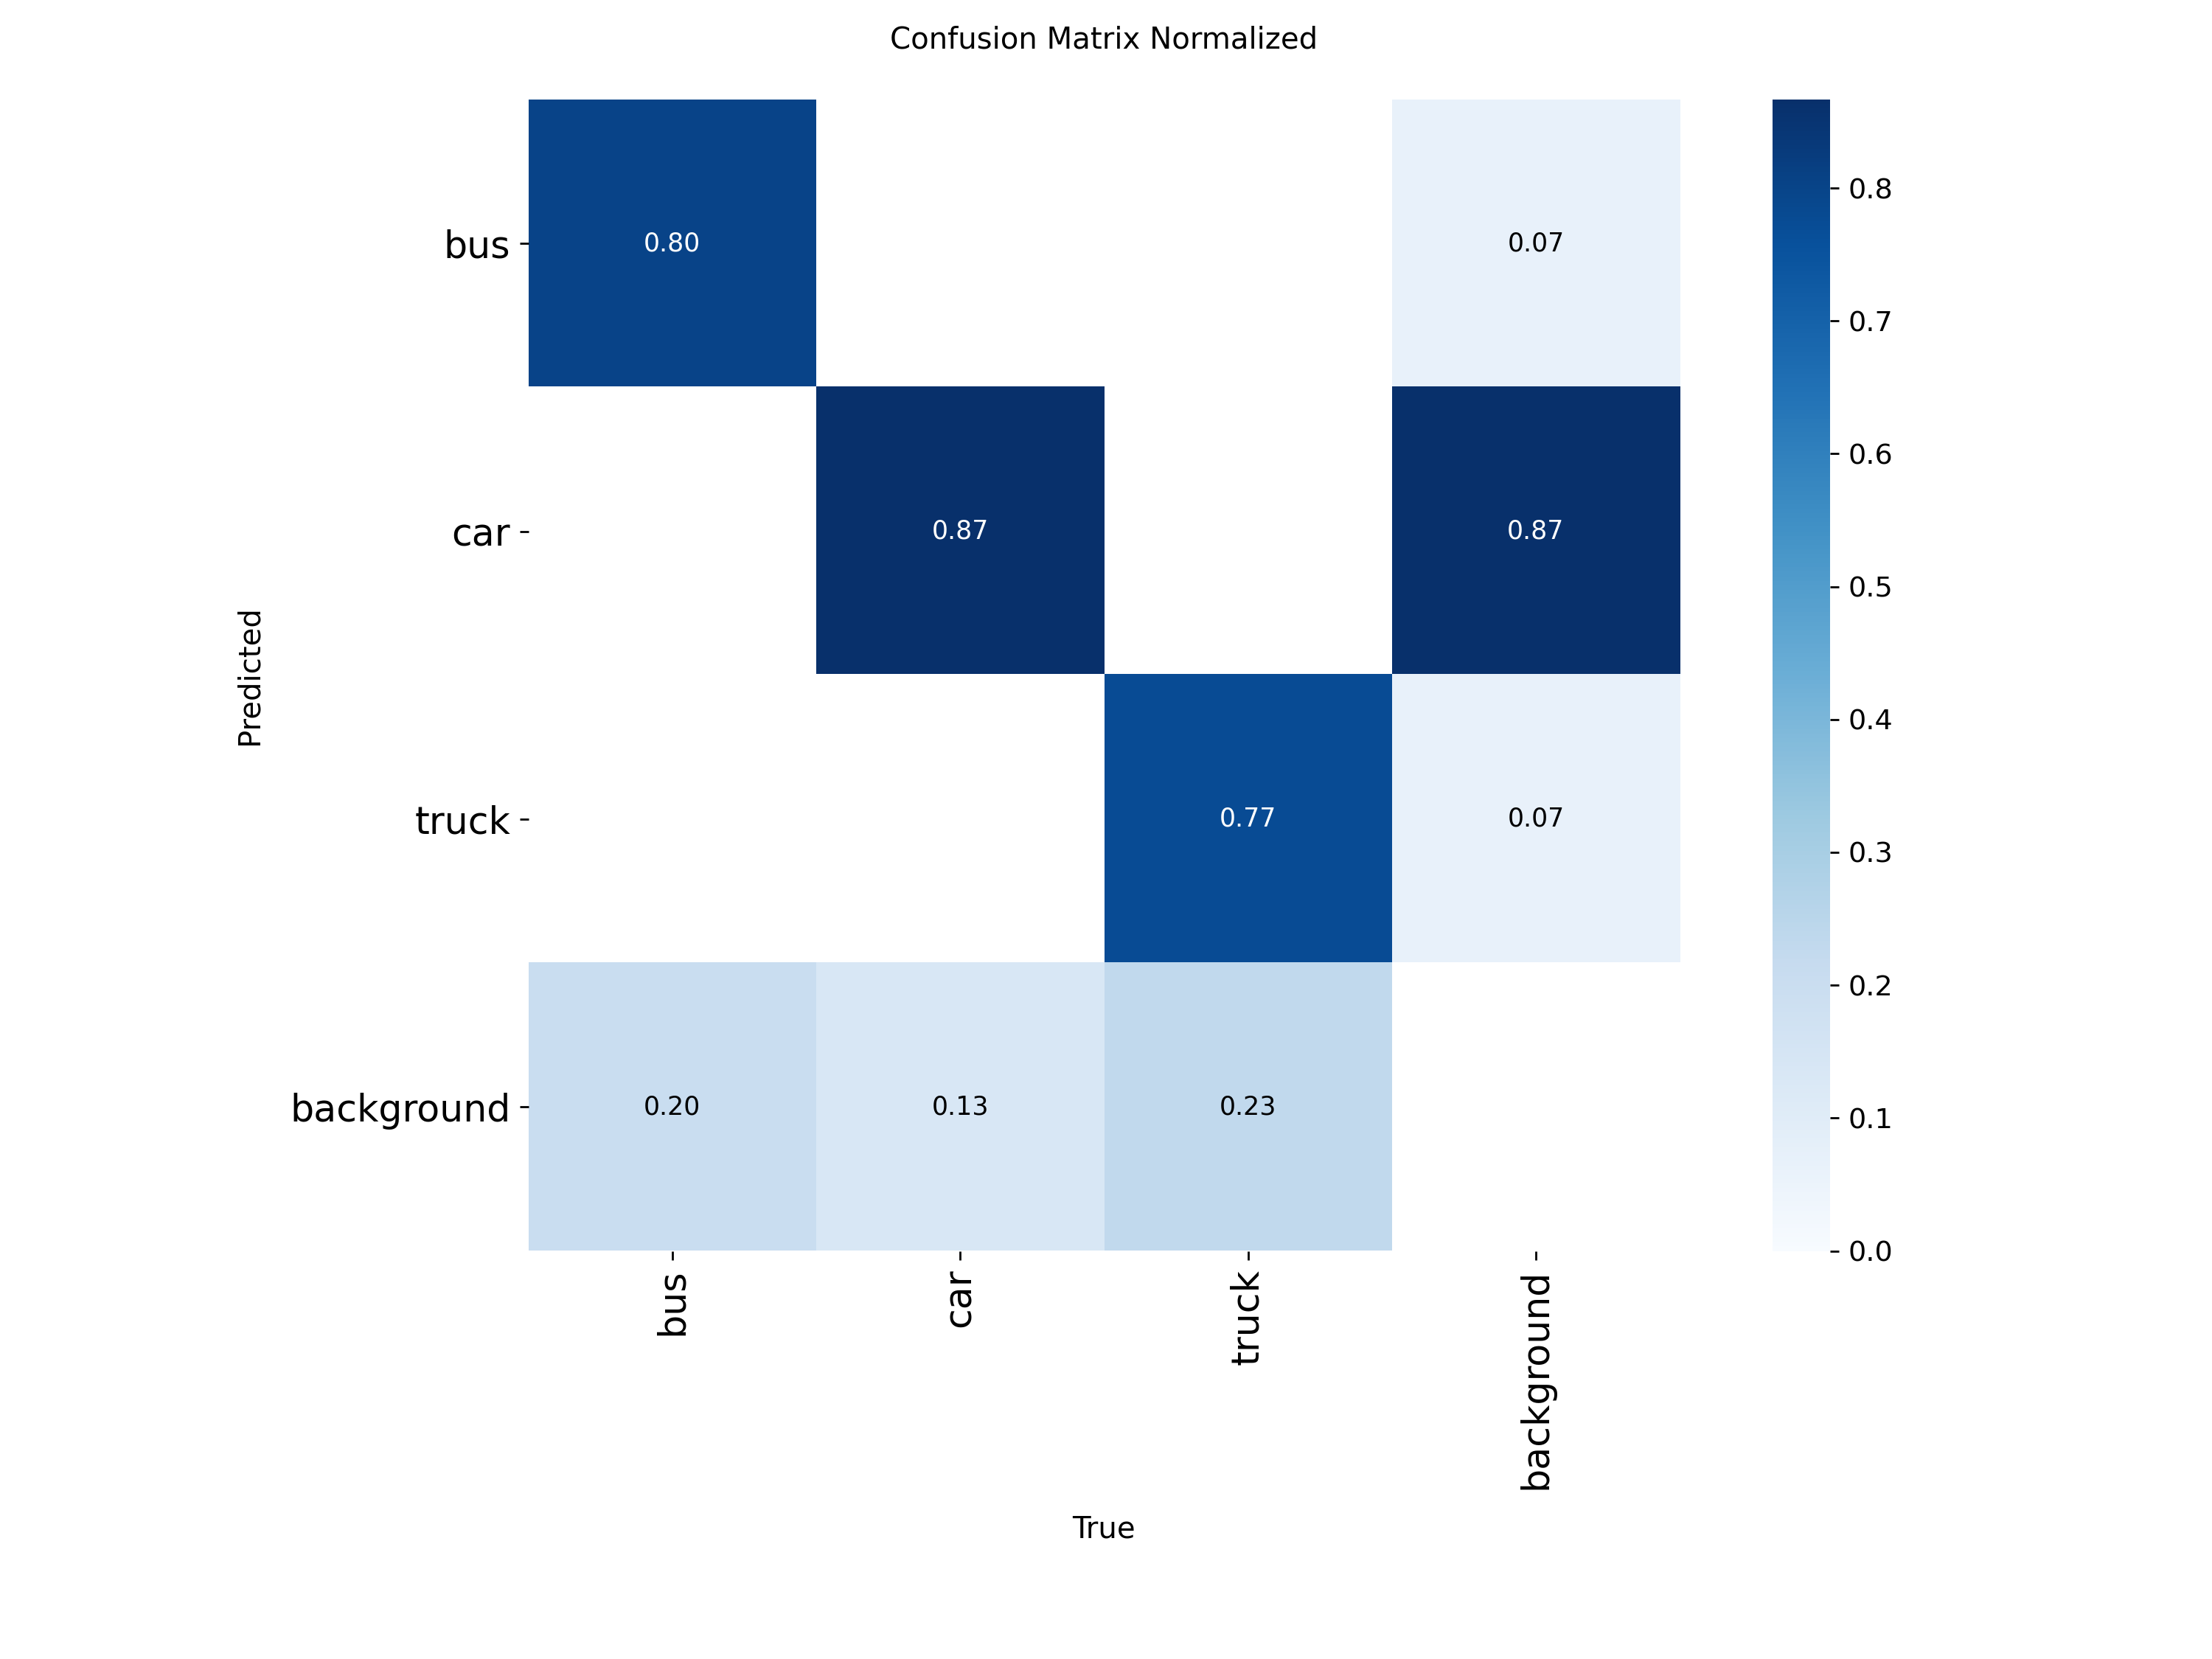


=== night ===


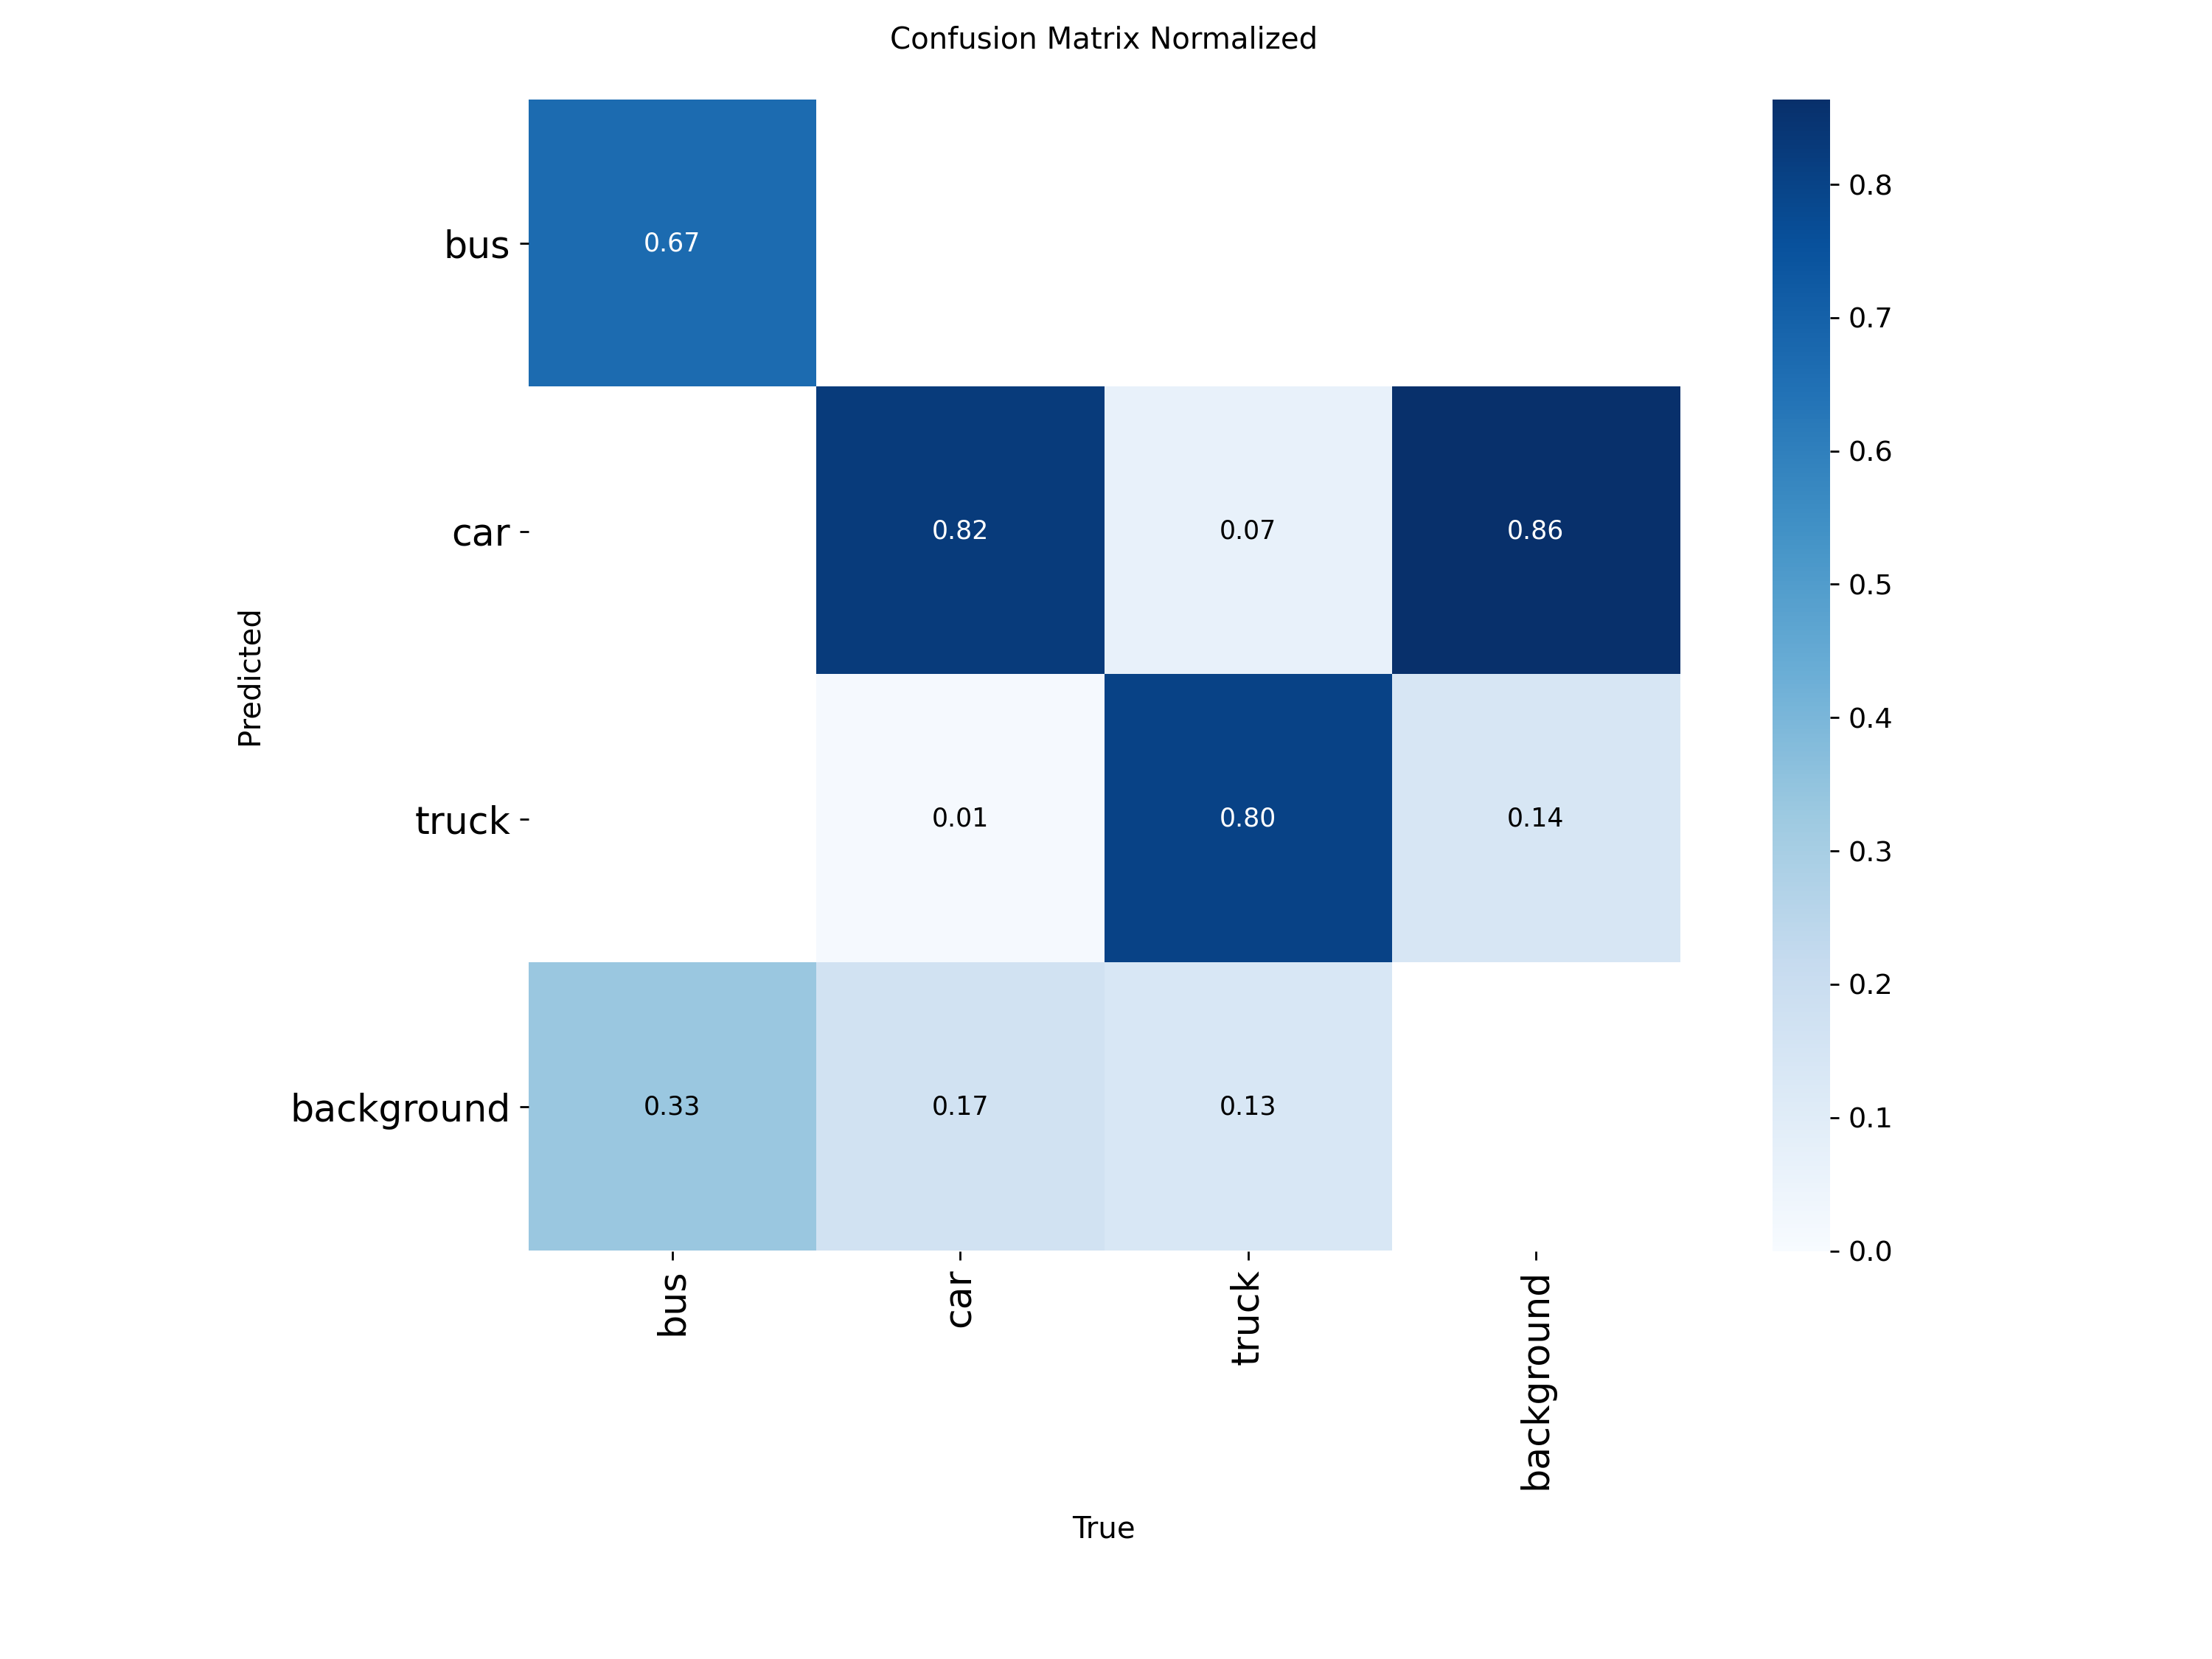


=== mixed ===


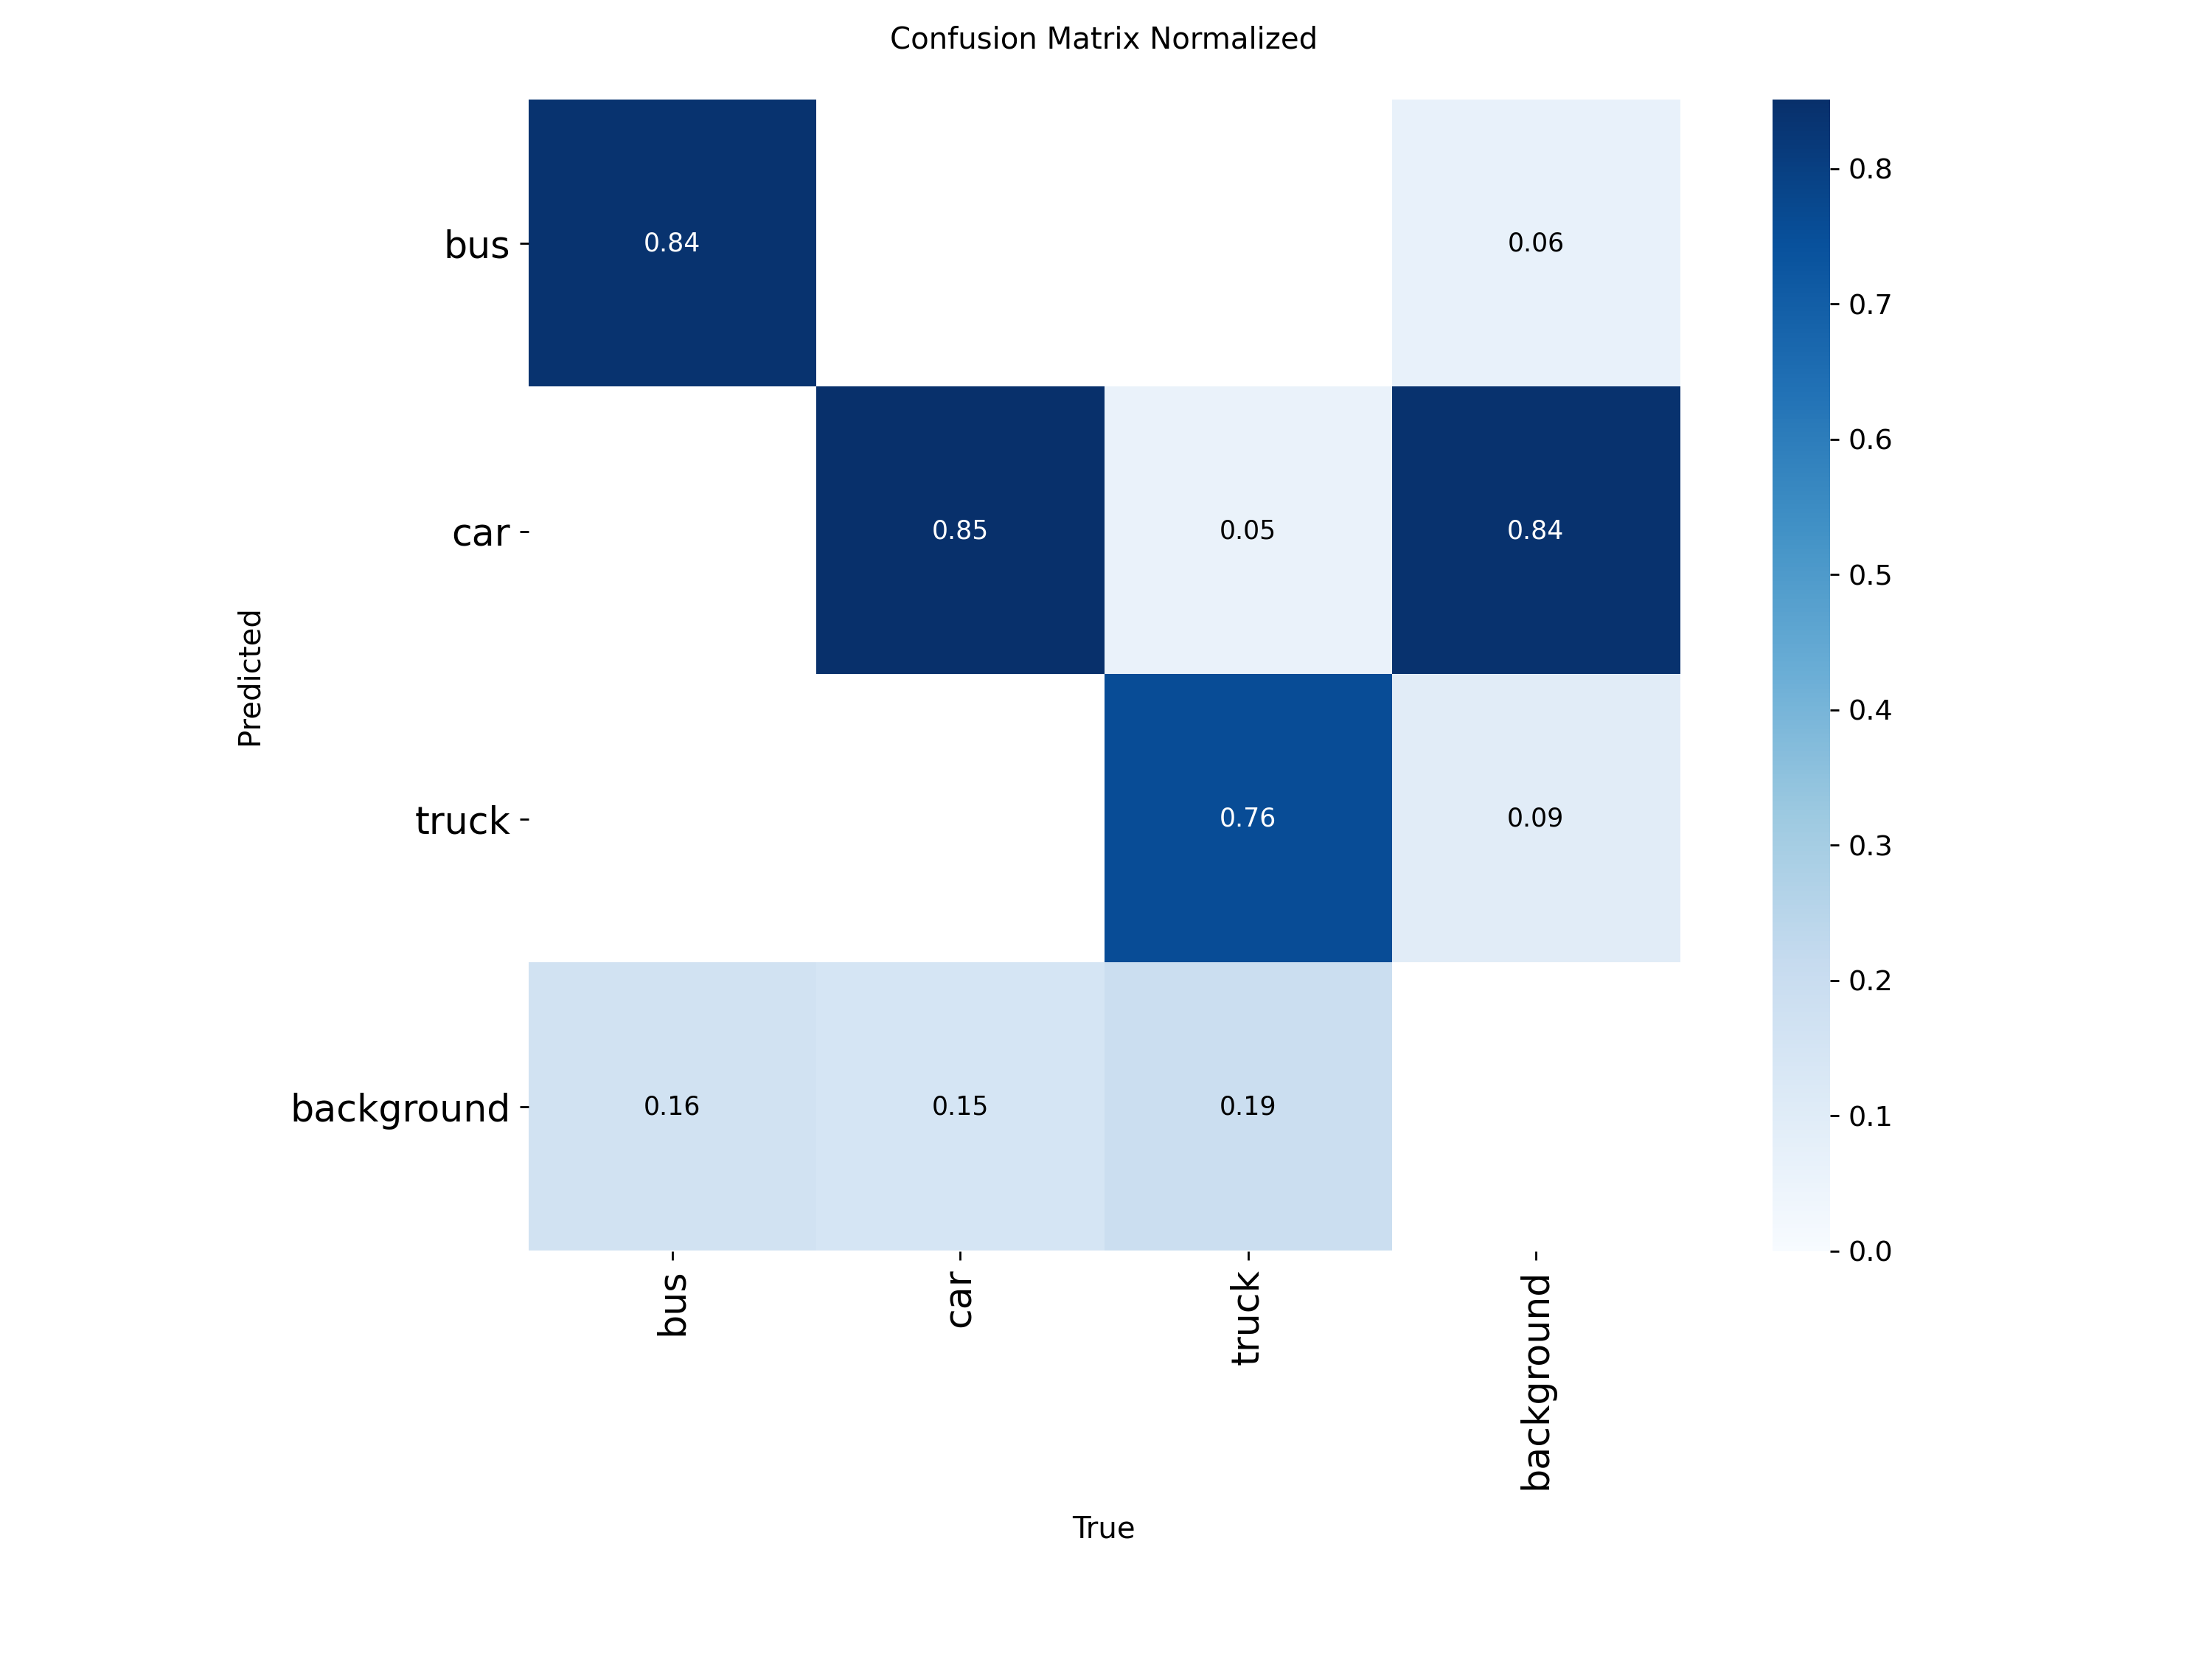

In [ ]:
from IPython.display import Image, display
import os


for name, model, data in [
    ("day", model_day, dataset_day.location),
    ("night", model_night, night_combined_path),
    ("mixed", model_no_aug, mixed_new_path),
]:
    model.val(
        data=f"{data}/data.yaml",
        imgsz=1280,
        plots=True,
        project="/content/confusion_matrices",
        name=name,
        verbose=False
    )
    print(f"{name} готово")

for name in ["day", "night", "mixed"]:
    print(f"\n=== {name} ===")
    display(Image(f"/content/confusion_matrices/{name}/confusion_matrix_normalized.png", width=600))

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from pathlib import Path
import os, shutil

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")


night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to day_dataset_1-1 in yolov11:: 100%|██████████| 407/407 [00:01<00:00, 221.50it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to night_dataset_1-1 in yolov11:: 100%|██████████| 253/253 [00:00<00:00, 516.40it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to dataset_night-4 in yolov11:: 100%|██████████| 149/149 [00:00<00:00, 528.63it/s]


Готово!


Mounted at /content/drive
Daytime  — mean: 133.9, std: 8.7
Nighttime — mean: 97.5, std: 19.9


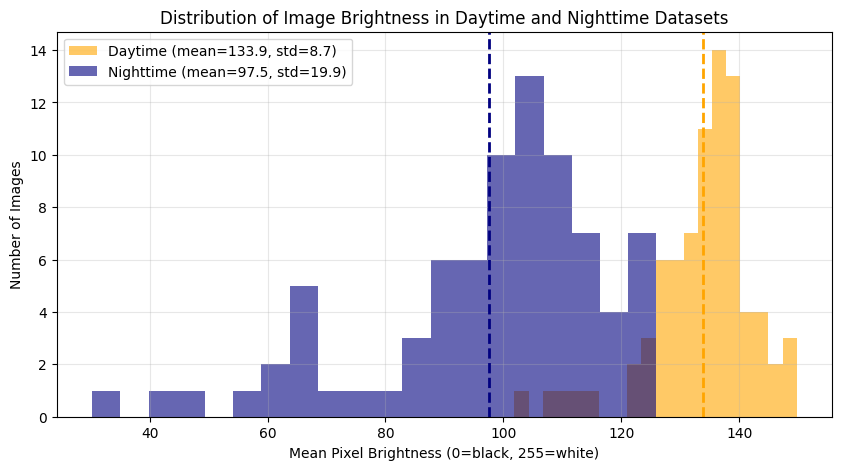

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

day_images = list(Path(f"{dataset_day.location}/train/images").iterdir()) + \
             list(Path(f"{dataset_day.location}/valid/images").iterdir())

night_images = list(Path(f"{night_combined_path}/train/images").iterdir()) + \
               list(Path(f"{night_combined_path}/valid/images").iterdir())

def get_brightness_values(image_paths, sample=80):
    brightness = []
    for img_path in image_paths[:sample]:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))
    return brightness

day_brightness = get_brightness_values(day_images)
night_brightness = get_brightness_values(night_images)

print(f"Daytime  — mean: {np.mean(day_brightness):.1f}, std: {np.std(day_brightness):.1f}")
print(f"Nighttime — mean: {np.mean(night_brightness):.1f}, std: {np.std(night_brightness):.1f}")

plt.figure(figsize=(10, 5))
plt.hist(day_brightness, bins=20, alpha=0.6, color='orange',
         label=f'Daytime (mean={np.mean(day_brightness):.1f}, std={np.std(day_brightness):.1f})')
plt.hist(night_brightness, bins=20, alpha=0.6, color='navy',
         label=f'Nighttime (mean={np.mean(night_brightness):.1f}, std={np.std(night_brightness):.1f})')
plt.axvline(np.mean(day_brightness), color='orange', linestyle='--', linewidth=2)
plt.axvline(np.mean(night_brightness), color='navy', linestyle='--', linewidth=2)
plt.title('Distribution of Image Brightness in Daytime and Nighttime Datasets')
plt.xlabel('Mean Pixel Brightness (0=black, 255=white)')
plt.ylabel('Number of Images')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/vehicle_detection/brightness_distribution_new.png", dpi=150)
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Ro


Extracting Dataset Version Zip to day_dataset_1-1 in yolov11:: 100%|██████████| 407/407 [00:08<00:00, 49.76it/s] 


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to night_dataset_1-1 in yolov11:: 100%|██████████| 253/253 [00:01<00:00, 190.20it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to dataset_night-4 in yolov11:: 100%|██████████| 149/149 [00:00<00:00, 207.70it/s]


Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1630.6±1092.8 MB/s, size: 2591.3 KB)
val: Scanning /content/day_dataset_1-1/valid/labels... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 505.2it/s 0.1s
val: New cache created: /content/day_dataset_1-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 32.4s/it 1:37
                   all         33        210        0.9      0.775      0.858       0.65
Speed: 27.0ms preprocess, 2689.0ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/confusion_matrices/day
day готово
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image a

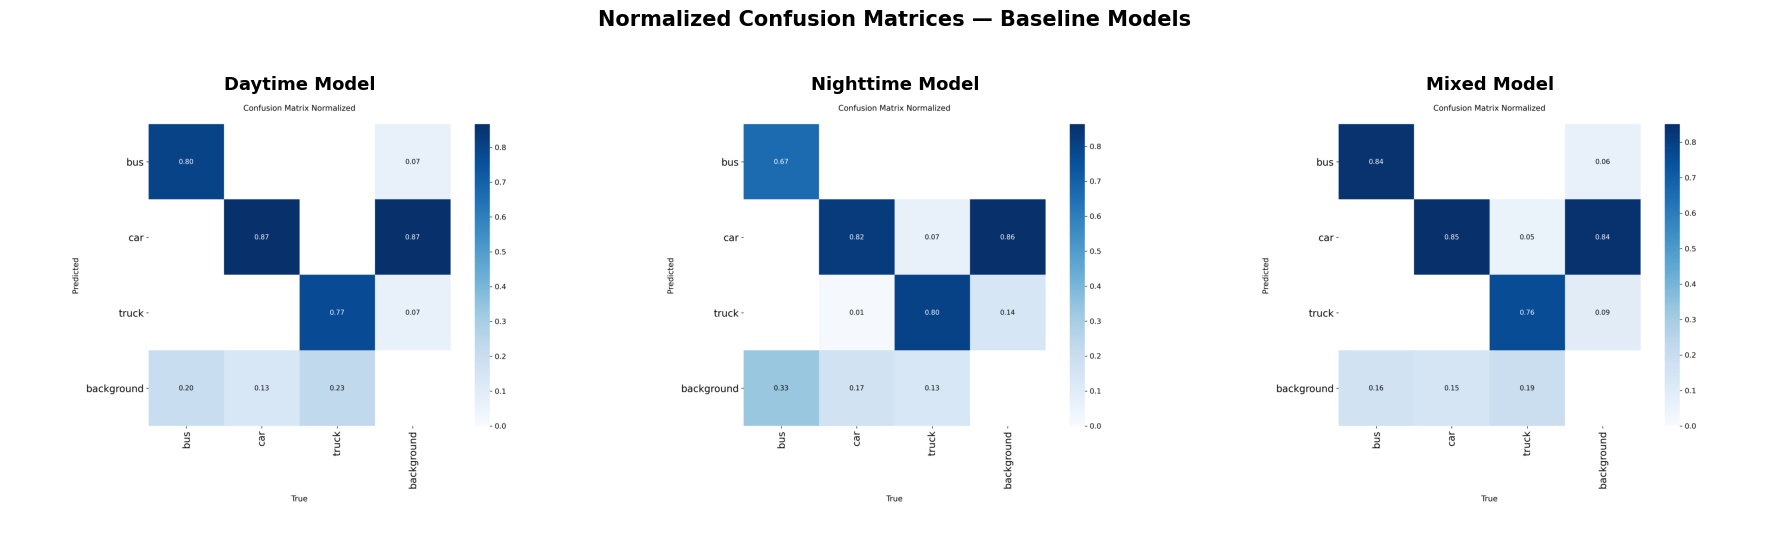

Сохранено на Drive!


In [ ]:
from pathlib import Path
from google.colab import drive
import os, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

drive.mount('/content/drive')

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")


night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


mixed_new_path = "/content/mixed_new"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{mixed_new_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{mixed_new_path}/{split}/labels", exist_ok=True)

for source in [dataset_day.location, night_combined_path]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{mixed_new_path}/{split}/{folder}/{f.name}")

with open(f"{mixed_new_path}/data.yaml", "w") as f:
    f.write(f"train: {mixed_new_path}/train/images\n")
    f.write(f"val: {mixed_new_path}/valid/images\n")
    f.write(f"test: {mixed_new_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")


model_day = YOLO("/content/drive/MyDrive/vehicle_detection/baseline/day_final_small_1280.pt")
model_night = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt")
model_no_aug = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/mixed_new_no_aug.pt")

for name, model, data in [
    ("day", model_day, dataset_day.location),
    ("night", model_night, night_combined_path),
    ("mixed", model_no_aug, mixed_new_path),
]:
    model.val(
        data=f"{data}/data.yaml",
        imgsz=1280,
        plots=True,
        project="/content/confusion_matrices",
        name=name,
        verbose=False
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["Daytime Model", "Nighttime Model", "Mixed Model"]
names = ["day", "night", "mixed"]

for ax, name, title in zip(axes, names, titles):
    img = mpimg.imread(f"/content/confusion_matrices/{name}/confusion_matrix_normalized.png")
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Normalized Confusion Matrices — Baseline Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/vehicle_detection/confusion_matrices_baseline.png", dpi=150)
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


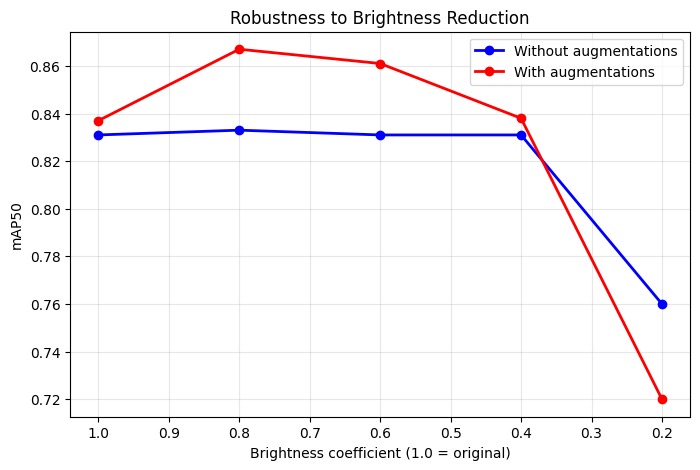

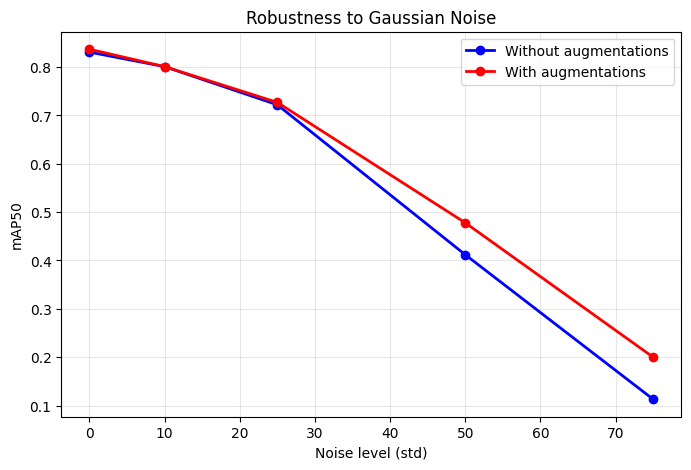

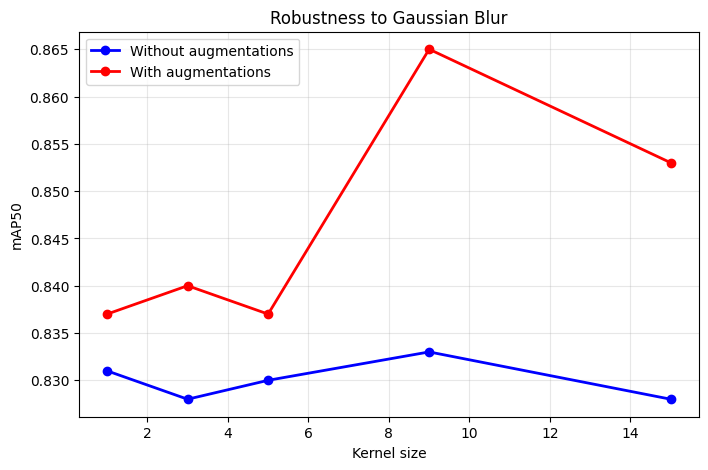

Все три графика сохранены!


In [ ]:
brightness_levels = [1.0, 0.8, 0.6, 0.4, 0.2]
noise_levels = [0, 10, 25, 50, 75]
blur_levels = [1, 3, 5, 9, 15]

map50_brightness_no_aug = [0.831, 0.833, 0.831, 0.831, 0.760]
map50_brightness_aug = [0.837, 0.867, 0.861, 0.838, 0.720]
map50_noise_no_aug = [0.831, 0.801, 0.722, 0.412, 0.113]
map50_noise_aug = [0.837, 0.801, 0.727, 0.478, 0.200]
map50_blur_no_aug = [0.831, 0.828, 0.830, 0.833, 0.828]
map50_blur_aug = [0.837, 0.840, 0.837, 0.865, 0.853]


plt.figure(figsize=(8, 5))
plt.plot(brightness_levels, map50_brightness_no_aug, 'b-o', linewidth=2, label='Without augmentations')
plt.plot(brightness_levels, map50_brightness_aug, 'r-o', linewidth=2, label='With augmentations')
plt.title('Robustness to Brightness Reduction')
plt.xlabel('Brightness coefficient (1.0 = original)')
plt.ylabel('mAP50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.savefig("/content/drive/MyDrive/vehicle_detection/robustness_brightness.png", dpi=150)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(noise_levels, map50_noise_no_aug, 'b-o', linewidth=2, label='Without augmentations')
plt.plot(noise_levels, map50_noise_aug, 'r-o', linewidth=2, label='With augmentations')
plt.title('Robustness to Gaussian Noise')
plt.xlabel('Noise level (std)')
plt.ylabel('mAP50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/vehicle_detection/robustness_noise.png", dpi=150)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(blur_levels, map50_blur_no_aug, 'b-o', linewidth=2, label='Without augmentations')
plt.plot(blur_levels, map50_blur_aug, 'r-o', linewidth=2, label='With augmentations')
plt.title('Robustness to Gaussian Blur')
plt.xlabel('Kernel size')
plt.ylabel('mAP50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("/content/drive/MyDrive/vehicle_detection/robustness_blur.png", dpi=150)
plt.show()

In [ ]:
!pip install ultralytics roboflow -q

from roboflow import Roboflow
from ultralytics import YOLO
from pathlib import Path
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

rf = Roboflow(api_key="xatN88B6QActzxTw7rFi")
dataset_day = rf.workspace("polinas-workspace").project("day_dataset_1").version(1).download("yolov11")
dataset_night1 = rf.workspace("polinas-workspace").project("night_dataset_1").version(1).download("yolov11")
dataset_night2 = rf.workspace("polinas-workspace").project("dataset_night").version(4).download("yolov11")

night_combined_path = "/content/night_combined"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{night_combined_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{night_combined_path}/{split}/labels", exist_ok=True)

for source in [dataset_night1.location, dataset_night2.location]:
    for split in ["train", "valid", "test"]:
        for folder in ["images", "labels"]:
            src = Path(f"{source}/{split}/{folder}")
            if src.exists():
                for f in src.iterdir():
                    shutil.copy(f, f"{night_combined_path}/{split}/{folder}/{f.name}")

with open(f"{night_combined_path}/data.yaml", "w") as f:
    f.write(f"train: {night_combined_path}/train/images\n")
    f.write(f"val: {night_combined_path}/valid/images\n")
    f.write(f"test: {night_combined_path}/test/images\n")
    f.write("nc: 3\n")
    f.write("names: ['bus', 'car', 'truck']\n")

model_day = YOLO("/content/drive/MyDrive/vehicle_detection/baseline/day_final_small_1280.pt")
model_night = YOLO("/content/drive/MyDrive/vehicle_detection/new_baseline/night_196_no_aug.pt")

model_day.val(
    data=f"{dataset_day.location}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="day",
    verbose=False
)


model_night.val(
    data=f"{night_combined_path}/data.yaml",
    imgsz=1280,
    plots=True,
    project="/content/f1_results",
    name="night",
    verbose=False
)


shutil.copy("/content/f1_results/day/BoxF1_curve.png",
            "/content/drive/MyDrive/vehicle_detection/f1_day.png")
shutil.copy("/content/f1_results/night/BoxF1_curve.png",
            "/content/drive/MyDrive/vehicle_detection/f1_night.png")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Rob


Extracting Dataset Version Zip to day_dataset_1-1 in yolov11:: 100%|██████████| 407/407 [00:04<00:00, 90.73it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to night_dataset_1-1 in yolov11:: 100%|██████████| 253/253 [00:01<00:00, 190.71it/s]

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset_night-4 in yolov11:: 100%|██████████| 149/149 [00:00<00:00, 405.13it/s]


Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2911.5±1698.9 MB/s, size: 2447.0 KB)
val: Scanning /content/day_dataset_1-1/valid/labels... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 473.6it/s 0.1s
val: New cache created: /content/day_dataset_1-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 31.4s/it 1:34
                   all         33        210        0.9      0.775      0.858       0.65
Speed: 18.2ms preprocess, 2632.6ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/f1_results/day
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±

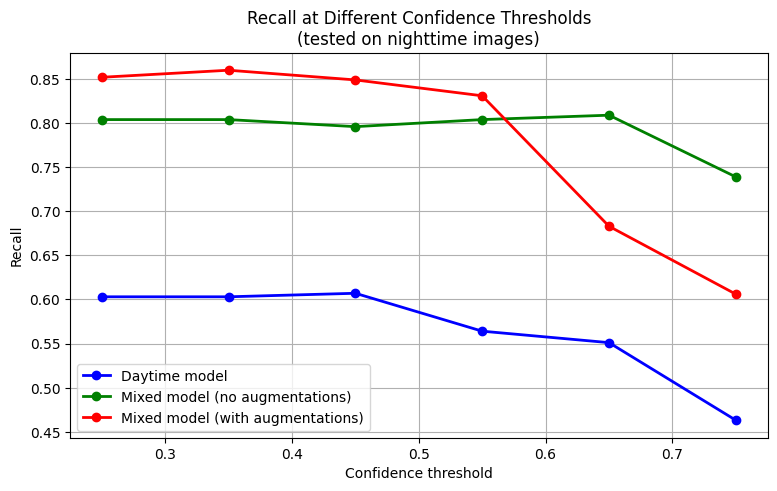

In [13]:
import matplotlib.pyplot as plt

conf_thresholds = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
recall_day = [0.603, 0.603, 0.607, 0.564, 0.551, 0.463]
recall_mixed_no_aug = [0.804, 0.804, 0.796, 0.804, 0.809, 0.739]
recall_mixed_aug = [0.852, 0.860, 0.849, 0.831, 0.683, 0.606]

plt.figure(figsize=(9, 5))
plt.plot(conf_thresholds, recall_day, 'b-o', linewidth=2, label='Daytime model')
plt.plot(conf_thresholds, recall_mixed_no_aug, 'g-o', linewidth=2, label='Mixed model (no augmentations)')
plt.plot(conf_thresholds, recall_mixed_aug, 'r-o', linewidth=2, label='Mixed model (with augmentations)')
plt.title('Recall at Different Confidence Thresholds\n(tested on nighttime images)')
plt.xlabel('Confidence threshold')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/vehicle_detection/recall_analysis_eng.png", dpi=150)
plt.show()